<a href="https://colab.research.google.com/github/knguyen0923/Equi-Metrics/blob/main/Equi_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kenneth Nguyen

# Table of Contents

1. Setup & Data Loading
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. EDA & Feature Engineering Key Findings
6. Data Preparation for Modeling
7. Modeling
8. Model Evaluation & Comparison
9. Feature Selection (Correlation)
10. Prediction Engine




# 1. Setup & Data Loading

## 1.1 Importing Libraries

In [ ]:
import pandas as pd
import requests
from sklearn.model_selection import train_test_split
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import os
from google.colab import drive

## 1.2 Mount Google Drive

In [ ]:
# Ensure the mount point is empty before mounting
if os.path.exists('/content/drive'):
    # Only remove contents if it's a directory and not already mounted
    if os.path.isdir('/content/drive') and not os.path.ismount('/content/drive'):
        print("Clearing existing content in /content/drive...")
        for item in os.listdir('/content/drive'):
            item_path = os.path.join('/content/drive', item)
            if os.path.isfile(item_path):
                os.remove(item_path)
            elif os.path.isdir(item_path):
                os.system(f'rm -rf {item_path}') # Use rm -rf for directories

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1.3 Create Folders for Datasets

In [ ]:
import os

base_path = "/content/drive/MyDrive/EquiMetrics"

folders = [
    "raw_data",
    "clean_data",
    "training_data",
    "testing_data",
    "models"
]

for folder in folders:
    os.makedirs(f"{base_path}/{folder}", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


## 1.4 Store API Key

In [ ]:
os.environ["RACING_API_KEY"] = "BCSw6ATaJLmgZGM07my7H2Hx"

## 1.5 Test the API

In [ ]:
api_key = os.getenv("RACING_API_KEY")

import requests
from requests.auth import HTTPBasicAuth

url = "https://api.theracingapi.com/v1/courses/regions"
params = {}
response = requests.request("GET", url, auth=HTTPBasicAuth('BCSw6ATaJLmgZGM07my7H2Hx','QshgVJBr3t5DjjIc7mN3hNoI'), params=params)
print(response.json())

## 1.6 Load Downloaded CSV
I was able to manually download the CSV file from May 26 2025 - May 26 2026 and got over 160k lines

In [ ]:
#Load CSV
df = pd.read_csv("/content/drive/MyDrive/EquiMetrics/raw_data/racingapidata.csv")


# 2. Data Cleaning & Preprocessing

## 2.1 Check Shape

In [ ]:
print("Shape:")
print(df.shape)

## 2.2 Print Head

In [ ]:
print("First 5 rows")
print(df.head())

## 2.3 Check Datatypes

In [ ]:
print("Datetypes")
print(df.dtypes)

## 2.4 Check Missing Values

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

## 2.5 Remove Duplicates

In [ ]:
df = df.drop_duplicates()
print(df.shape)

## 2.6 Convert Dates if available

In [ ]:
if "race_date" in df.columns:
  df["race_date"]=pd.to_datetime(df["race_date"])
print(df.shape)

## 2.7 Fill Missing Values

In [ ]:
df = df.fillna(0)
print(df.shape)

## 2.8 Print Columns

In [ ]:
print(df.columns)

## 2.9 Check Missing/Incomplete Features

In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing.sort_values(ascending=False))

## 2.10 Features I am using

# Race
'race_region',
'race_course',
'race_type',
'race_class',
'race_dist',
'race_going',
'race_surface',

# Horse
'runner_age',
'runner_sex',
'runner_weight_lbs',
'runner_draw',
'runner_headgear',
'runner_or',
'runner_rpr',
'runner_tsr',

# Betting
'runner_sp_dec',
'runner_bsp',

# Human factors
'runner_jockey',
'runner_trainer'

target='runner_position'

## 2.11 Transform Object Features to Numeric

In [ ]:
selected_features = [
    'race_region', 'race_course', 'race_type', 'race_class',
    'race_going', 'race_surface',
    'runner_age', 'runner_sex', 'runner_weight_lbs', 'runner_draw',
    'runner_headgear', 'runner_or', 'runner_rpr', 'runner_tsr',
    'runner_sp_dec', 'runner_bsp',
    'runner_jockey', 'runner_trainer',
    'race_dist_meters'
]

target = 'runner_position'

# Filter only if the columns exist to avoid KeyErrors
existing_cols = [c for c in selected_features if c in df.columns]
model_df = df[existing_cols + [target]].copy()

# Ensure position is numeric
model_df[target] = pd.to_numeric(model_df[target], errors='coerce')
model_df = model_df.dropna(subset=[target])
model_df[target] = model_df[target].astype(int)

print(f"Corrected model_df shape: {model_df.shape}")

In [ ]:
model_df.columns


# 3. Exploratory Data Analysis (EDA)

## 3.0 Initial Cleaning & EDA

In [ ]:
# Count race types
race_type_counts = model_df['race_type'].value_counts()

# Create bar chart
plt.figure(figsize=(10,6))

race_type_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.xlabel('Race Type')
plt.ylabel('Number of Races')
plt.title('Distribution of Race Types')

plt.xticks(rotation=45)


This bar chart displays the distribution of different race types within the dataset, highlighting the prevalence of Flat races compared to other types like Hurdle, Chase, and NH Flat.

### 3.0.1 Limit the Data to Flat Racing

In [ ]:
model_df = model_df[
    model_df['race_type'] == 'Flat'
]

In [ ]:
print(model_df['race_region'].value_counts())

### 3.0.2 Map of the full dataset

In [ ]:
import plotly.express as px

# Get unique regions
map_df = model_df[['race_region']].dropna().drop_duplicates()

# Convert racing region codes to ISO-3 country codes
country_map = {
    'GB': 'GBR',
    'IRE': 'IRL',
    'FR': 'FRA',
    'HK': 'HKG',
    'AUS': 'AUS',
    'USA': 'USA',
    'UAE': 'ARE',
    'JPN': 'JPN',
    'GER': 'DEU',
    'BHR': 'BHR',
    'ARG': 'ARG',
    'SAF': 'ZAF',
    'CAN': 'CAN',
    'BRZ': 'BRA',
    'ITY': 'ITA',
    'NZ': 'NZL',
    'CHI': 'CHL',
    'JER': 'JEY',
    'KSA': 'SAU',
    'PER': 'PER',
    'QA': 'QAT',
    'SWE': 'SWE',
    'TUR': 'TUR',
    'URU': 'URY',
    'KOR': 'KOR',
    'SWI': 'CHE',
    'HUN': 'HUN',
    'POL': 'POL',
    'CZE': 'CZE',
    'NOR': 'NOR'
}

# Apply mapping
map_df['iso_code'] = map_df['race_region'].map(country_map)

# Remove unmapped rows
map_df = map_df.dropna(subset=['iso_code'])

# Highlight countries
map_df['Included'] = 'Yes'

# Create map
fig = px.choropleth(
    map_df,
    locations='iso_code',
    color='Included',
    hover_name='race_region',
    title='Countries Included in Equi-Metrics Dataset'
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True)
)

fig.show()

The dataset contains races from a wide range of countries and racing environments. Great Britain contributed the largest proportion of races, followed by France, Ireland, Hong Kong, and Australia.
This international coverage is valuable because it introduces variation in:
*   track surfaces
*   race distance
*   training styles
*   horse development systems

The diversity of racing jurisdictions improves the robustness of future machine learning models and reduces overfitting to a single racing region.


### 3.0.3 Convert to numeric Betting Odds Features

In [ ]:
model_df['runner_sp_dec'] = pd.to_numeric(
    model_df['runner_sp_dec'],
    errors='coerce'
)

model_df['runner_bsp'] = pd.to_numeric(
    model_df['runner_bsp'],
    errors='coerce'
)

In [ ]:
print(model_df[['runner_sp_dec', 'runner_bsp']].describe())

### 3.0.4 Coverting Rating Columns to numeric

In [ ]:
rating_cols = [
    'runner_or',
    'runner_rpr',
    'runner_tsr'
]

for col in rating_cols:
    model_df[col] = pd.to_numeric(
        model_df[col],
        errors='coerce'
    )


In [ ]:
print(model_df[['runner_or', 'runner_rpr','runner_tsr']].describe())
model_df[['runner_or', 'runner_rpr','runner_tsr']].shape

### 3.0.5 Weight Columns

In [ ]:
model_df['runner_weight_lbs'] = pd.to_numeric(
    model_df['runner_weight_lbs'],
    errors='coerce'
)

In [ ]:
print(model_df[['runner_weight_lbs']].describe())

### 3.0.6 Add a meter distance column for easier converstion

In [ ]:
# Ensure 'race_dist_y' is available in model_df
# It was not included in the initial model_df creation, so we retrieve it from the original df.
# The indices align since model_df is a filtered view of df.
if 'race_dist_y' not in model_df.columns and 'race_dist_y' in df.columns:
    model_df['race_dist_y'] = df.loc[model_df.index, 'race_dist_y']
elif 'race_dist_y' not in df.columns:
    print("Warning: 'race_dist_y' not found in the original 'df' DataFrame. Conversion may not be possible.")

# Convert yards to meters
model_df['race_dist_meters'] = (
    model_df['race_dist_y'] * 0.9144
)

# Preview
print(
    model_df[
        ['race_dist_y', 'race_dist_meters']
    ].head()
)

In [ ]:
model_df = model_df.drop(columns=['race_dist_y'])


In [ ]:
print(model_df.columns)

## 3.1 Horse Demographics
### Gender Distribution

# 4. Feature Engineering

## 4.1 Pedigree Features

In [ ]:
pd.set_option('future.no_silent_downcasting', True)

df = pd.read_csv("/content/drive/MyDrive/EquiMetrics/raw_data/racingapidata.csv")

df["race_date"] = pd.to_datetime(df["race_date"], errors="coerce")
df = df.sort_values("race_date").reset_index(drop=True)

df["winner"] = (pd.to_numeric(df["runner_position"], errors="coerce") == 1).astype(int)

df["runner_rpr"] = pd.to_numeric(df["runner_rpr"], errors="coerce")
df["runner_tsr"] = pd.to_numeric(df["runner_tsr"], errors="coerce")

### 4.1.1 Historical Sires (Father) Features

In [ ]:
if "winner" not in df.columns:
    df["winner"] = (pd.to_numeric(df["runner_position"], errors="coerce") == 1).astype(int)

df["sire_starts_before" ] = df.groupby("runner_sire_id").cumcount()

df["sire_wins_before"] = (
    df.groupby("runner_sire_id")["winner"]
      .cumsum()
      .groupby(df["runner_sire_id"])
      .shift(1)
)
df["sire_sample_size"] = df["sire_starts_before"]

df["sire_win_rate"] = df["sire_wins_before"] / df["sire_starts_before"]

df["sire_avg_rpr"] = (
    df.groupby("runner_sire_id")["runner_rpr"]
      .transform(lambda x: x.expanding().mean().shift(1))
)

df["sire_avg_tsr"] = (
    df.groupby("runner_sire_id")["runner_tsr"]
      .transform(lambda x: x.expanding().mean().shift(1))
)

### 4.1.2 Historical Damsire (Maternal Grandfather) Features

In [ ]:
df["damsire_starts_before"] = df.groupby("runner_damsire_id").cumcount()

df["damsire_wins_before"] = (
    df.groupby("runner_damsire_id")["winner"]
      .cumsum()
      .groupby(df["runner_damsire_id"])
      .shift(1)
)

df["damsire_sample_size"] = df["damsire_starts_before"]

df["damsire_win_rate"] = df["damsire_wins_before"] / df["damsire_starts_before"]

df["damsire_avg_rpr"] = (
    df.groupby("runner_damsire_id")["runner_rpr"]
      .transform(lambda x: x.expanding().mean().shift(1))
)

df["damsire_avg_tsr"] = (
    df.groupby("runner_damsire_id")["runner_tsr"]
      .transform(lambda x: x.expanding().mean().shift(1))
)

### 4.1.3 Dam/Broodmare (Mother) Features

In [ ]:
df["dam_starts_before"] = df.groupby("runner_dam_id").cumcount()

df["dam_wins_before"] = (
    df.groupby("runner_dam_id")["winner"]
      .cumsum()
      .groupby(df["runner_dam_id"])
      .shift(1)
)

df["dam_sample_size"] = df["dam_starts_before"]

df["dam_win_rate"] = df["dam_wins_before"] / df["dam_starts_before"]

df["dam_avg_rpr"] = (
    df.groupby("runner_dam_id")["runner_rpr"]
      .transform(lambda x: x.expanding().mean().shift(1))
)

df["dam_avg_tsr"] = (
    df.groupby("runner_dam_id")["runner_tsr"]
      .transform(lambda x: x.expanding().mean().shift(1))
)

### 4.1.4 Simple Pedigree Score

In [ ]:
pedigree_cols = [
    "sire_win_rate",
    "sire_avg_rpr",
    "sire_avg_tsr",
    "damsire_win_rate",
    "damsire_avg_rpr",
    "damsire_avg_tsr",
    "dam_win_rate",
    "dam_avg_rpr",
    "dam_avg_tsr"
]

df[pedigree_cols] = df[pedigree_cols].fillna(0).infer_objects(copy=False)

df["pedigree_score"] = (
    df["sire_win_rate"] * 0.22 +
    df["sire_avg_rpr"] * 0.18 +
    df["sire_avg_tsr"] * 0.12 +

    df["damsire_win_rate"] * 0.15 +
    df["damsire_avg_rpr"] * 0.10 +
    df["damsire_avg_tsr"] * 0.08 +

    df["dam_win_rate"] * 0.08 +
    df["dam_avg_rpr"] * 0.05 +
    df["dam_avg_tsr"] * 0.02
)

The math only suggests Sire > Damsire > Dam in thouroghbred flat horseracing

### 4.1.5 Check columns

In [ ]:
df[pedigree_cols].head()

In [ ]:
df[pedigree_cols].isnull().sum()

### 4.1.6 Pedigree Column Graphs

In [ ]:

pedigree_cols = [
    "sire_win_rate",
    "sire_avg_rpr",
    "sire_avg_tsr",

    "damsire_win_rate",
    "damsire_avg_rpr",
    "damsire_avg_tsr",

    "dam_win_rate",
    "dam_avg_rpr",
    "dam_avg_tsr",

    "sire_sample_size",
    "damsire_sample_size",
    "dam_sample_size",
]

df[pedigree_cols].hist(figsize=(16, 12))

plt.tight_layout()
plt.show()

These histograms display the distributions of various pedigree-related features, such as sire win rate, average RPR, and sample sizes for sire, damsire, and dam. They provide insights into the spread and characteristics of these engineered features.

### 4.1.7 Pedigree Score Graph

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["pedigree_score"], bins=30)

plt.title("Distribution of Pedigree Score")
plt.xlabel("Pedigree Score")
plt.ylabel("Frequency")

plt.show()

This histogram shows the distribution of the calculated pedigree score, indicating the spread of pedigree strength among horses in the dataset.

In [ ]:
df["pedigree_score"].describe()

### 4.1.8 Pedigree Score vs Winning

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="winner",
    y="pedigree_score",
    data=df
)

plt.title("Pedigree Score vs Winning")

plt.show()

This boxplot compares the pedigree score of winning horses versus non-winning horses, indicating if there's a noticeable difference in pedigree scores between these groups.

In [ ]:
print("Columns in original df:")
print(df[["runner_horse", "race_date"]].head())

print("\nColumns available in model_df:")
print(model_df.columns.tolist())

print("\nFirst 5 rows of model_df:")
print(model_df.head())

### 4.1.9 Merge the two dataframes

In [ ]:
merge_cols = [
    "race_race_id",
    "runner_horse_id"
]

In [ ]:
pedigree_cols = [
    "sire_win_rate",
    "sire_avg_rpr",
    "sire_avg_tsr",
    "sire_sample_size",

    "damsire_win_rate",
    "damsire_avg_rpr",
    "damsire_avg_tsr",
    "damsire_sample_size",

    "dam_win_rate",
    "dam_avg_rpr",
    "dam_avg_tsr",
    "dam_sample_size",
    "pedigree_score"
]

# Ensure ID columns are in model_df before merging
for col in merge_cols:
    if col not in model_df.columns:
        model_df[col] = df.loc[model_df.index, col]

model_df = model_df.merge(
    df[merge_cols + pedigree_cols],
    on=merge_cols,
    how="left"
)

print(f"New model_df shape: {model_df.shape}")
print("Pedigree features successfully merged.")

In [ ]:
# Verify the merge and check for nulls in the new features
pedigree_summary = model_df[pedigree_cols].isnull().sum()
print("Null counts in merged pedigree columns:")
print(pedigree_summary)

# Fill any NaN values from the merge with 0 (for cases where no pedigree data was found)
model_df[pedigree_cols] = model_df[pedigree_cols].fillna(0)

print("\nUpdated model_df preview (first 5 rows):")
display(model_df.head())

In [ ]:
model_df.columns

### 4.1.10 Horse ID lookup

In [ ]:
horse_lookup = (
    df[["runner_horse_id", "runner_horse"]]
    .drop_duplicates()
)

model_df = model_df.merge(
    horse_lookup,
    on="runner_horse_id",
    how="left"
)

In [ ]:
model_df[["runner_horse_id", "runner_horse"]].head()

In [ ]:
model_df.columns

In [ ]:
horse_col = model_df.pop("runner_horse")
model_df.insert(0, "runner_horse", horse_col)

### 4.1.11 Move horse names to first column

In [ ]:
model_df.columns

In [ ]:
model_df.info()

In [ ]:
model_df.columns

## 4.2 Elo Rating System

In [ ]:
# Add race_date if model_df does not already have it
if "race_date" not in model_df.columns:
    model_df = model_df.merge(
        df[["race_race_id", "runner_horse_id", "race_date"]],
        on=["race_race_id", "runner_horse_id"],
        how="left"
    )

model_df["race_date"] = pd.to_datetime(model_df["race_date"])

# Sort chronologically to avoid data leakage
model_df = model_df.sort_values(["race_date", "race_race_id"]).copy()

elo_ratings = {}
initial_elo = 1500
k = 20

model_df["horse_elo_before"] = np.nan

for race_id, race in model_df.groupby("race_race_id", sort=False):
    horses = race["runner_horse_id"].tolist()
    positions = race["runner_position"].tolist()

    # Elo before this race
    for idx, horse_id in zip(race.index, horses):
        model_df.loc[idx, "horse_elo_before"] = elo_ratings.get(horse_id, initial_elo)

    updates = {horse_id: 0 for horse_id in horses}

    # Pairwise matchups inside each race
    for i in range(len(horses)):
        for j in range(i + 1, len(horses)):
            horse_a = horses[i]
            horse_b = horses[j]

            pos_a = positions[i]
            pos_b = positions[j]

            rating_a = elo_ratings.get(horse_a, initial_elo)
            rating_b = elo_ratings.get(horse_b, initial_elo)

            expected_a = 1 / (1 + 10 ** ((rating_b - rating_a) / 400))
            expected_b = 1 - expected_a

            if pos_a < pos_b:
                score_a = 1
                score_b = 0
            elif pos_a > pos_b:
                score_a = 0
                score_b = 1
            else:
                score_a = 0.5
                score_b = 0.5

            updates[horse_a] += k * (score_a - expected_a)
            updates[horse_b] += k * (score_b - expected_b)

    # Apply updates after the race
    for horse_id in horses:
        elo_ratings[horse_id] = elo_ratings.get(horse_id, initial_elo) + updates[horse_id]

### 4.2.1 Race relative elo

In [ ]:
model_df["horse_elo_rank"] = (
    model_df.groupby("race_race_id")["horse_elo_before"]
    .rank(ascending=False, method="dense")
)

model_df["horse_elo_vs_race_avg"] = (
    model_df["horse_elo_before"] -
    model_df.groupby("race_race_id")["horse_elo_before"].transform("mean")
)

In [ ]:
elo_cols = [
    "horse_elo_before",
    "horse_elo_rank",
    "horse_elo_vs_race_avg"
]


In [ ]:
selected_features = selected_features + elo_cols

In [ ]:
model_df[[
    "runner_horse",
    "race_date",
    "race_race_id",
    "runner_position",
    "horse_elo_before",
    "horse_elo_rank",
    "horse_elo_vs_race_avg"
]].tail(20)

In [ ]:
model_df[[
    "runner_horse",
    "race_date",
    "race_race_id",
    "runner_position",
    "horse_elo_before",
    "horse_elo_rank",
    "horse_elo_vs_race_avg"
]].describe()

### 4.2.2 KDE Curve

In [ ]:

model_df["horse_elo_before"].plot(
    kind="density",
    figsize=(10, 6)
)

plt.title("Horse Elo Distribution")
plt.xlabel("Elo Rating")

plt.show()

This KDE (Kernel Density Estimate) plot illustrates the distribution of horse Elo ratings before a race, showing the overall spread and density of Elo scores.

### 4.2.3 Histogram + KDE Together

In [ ]:
plt.figure(figsize=(12, 6))

model_df["horse_elo_before"].hist(
    bins=50,
    density=True
)

model_df["horse_elo_before"].plot(
    kind="density"
)

plt.title("Horse Elo Distribution")
plt.xlabel("Elo Rating")

plt.show()

This combined plot shows both the histogram and the KDE curve of horse Elo ratings before a race, providing a comprehensive view of the distribution and density of Elo scores.

### 4.2.4 Boxplot to see outliers

In [ ]:
plt.figure(figsize=(12, 2))

plt.boxplot(
    model_df["horse_elo_before"].dropna(),
    vert=False
)

plt.title("Horse Elo Boxplot")
plt.xlabel("Elo Rating")

plt.show()

This boxplot for horse Elo ratings visually identifies the median, quartiles, and potential outliers in the distribution of Elo scores.

In [ ]:
q1 = model_df["horse_elo_before"].quantile(0.25)
q3 = model_df["horse_elo_before"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Median:", model_df["horse_elo_before"].median())
print("Q3:", q3)
print("IQR:", iqr)

print("Lower Outlier Bound:", lower_bound)
print("Upper Outlier Bound:", upper_bound)

### 4.2.5 Elite/Outlier Horses

In [ ]:
model_df[
    model_df["horse_elo_before"] > upper_bound
][[
    "runner_horse",
    "horse_elo_before",
    "race_class",
    "runner_position"
]].sort_values("horse_elo_before", ascending=False)

### 4.2.6 Distribution by race class

In [ ]:
# Convert race_class to string to ensure consistent sorting of mixed types (int and str)
classes = sorted(model_df["race_class"].astype(str).unique())

plt.figure(figsize=(12, 6))

for race_class in classes:
    subset = model_df[
        model_df["race_class"].astype(str) == race_class
    ]

    subset["horse_elo_before"].plot(
        kind="density",
        label=f"Class {race_class}"
    )

plt.legend()
plt.title("Elo Distribution by Race Class")
plt.xlabel("Elo Rating")
plt.show()

This density plot illustrates the distribution of Elo ratings for horses across different race classes, allowing for a comparison of Elo score ranges in various competition levels.

### 4.2.7 Top Horse

In [ ]:
top_horse = (
    model_df.groupby("runner_horse")["horse_elo_before"]
    .max()
    .idxmax()
)

horse_df = model_df[
    model_df["runner_horse"] == top_horse
].sort_values("race_date")

plt.figure(figsize=(12, 6))

plt.plot(
    horse_df["race_date"],
    horse_df["horse_elo_before"]
)

plt.title(f"Elo Progression: {top_horse}")
plt.xlabel("Race Date")
plt.ylabel("Elo")

plt.show()

This line plot displays the progression of the Elo rating over time for the horse with the highest maximum Elo score, showing how its rating evolved across different races.

### 4.2.8 Distribution of Class 1,2,3 Horses

In [ ]:
plt.figure(figsize=(12, 6))

# Using string labels to match the data format in model_df
for race_class in ['Class 1', 'Class 2', 'Class 3']:
    subset = model_df[
        model_df["race_class"].astype(str) == race_class
    ]

    # Only plot if the subset actually contains data to avoid ValueErrors
    if not subset.empty:
        subset["horse_elo_before"].plot(
            kind="density",
            label=race_class
        )

plt.title("Horse Elo Distribution for Classes 1, 2, and 3")
plt.xlabel("Elo Rating")
plt.ylabel("Density")

plt.legend()
plt.show()

This density plot compares the distribution of horse Elo ratings specifically for Class 1, Class 2, and Class 3 races, highlighting the typical Elo ranges for top-tier competitions.

In [ ]:
model_df.columns

In [ ]:
model_df.size

### 4.2.9 Boxplot of Winners and Elo

In [ ]:
sns.boxplot(
    x='winner',
    y='horse_elo_before',
    data=model_df
)

plt.title('ELO vs Winning')
plt.show()

This boxplot shows the distribution of horse Elo ratings for winners versus non-winners, indicating if horses with higher Elo ratings are more likely to win.

In [ ]:
sns.violinplot(
    x='winner',
    y='horse_elo_before',
    data=model_df
)

plt.title("ELO Distribution by Winner")
plt.show()

This violin plot visualizes the density and distribution of Elo ratings for winners and non-winners. While the medians are similar, winners show a slightly different density profile in the higher Elo ranges.

An elo rating system was implemented to capture horse performance trends over time. Due to the limited historical dataset (1 year of racing), elo ratings remained relatively concentrated around their initial value and demonstrated limited standalone predictive power. However, the feature was retained as it may provide additional signal when combined with traditional perofrmance metrics such as TSR, RPR and Official Rating

In [ ]:
model_df['elo_bucket'] = pd.cut(
    model_df['horse_elo_before'],
    bins=[0,1300,1400,1500,1600,1700,2500]
)

win_rates = (
    model_df.groupby('elo_bucket')['winner']
    .mean()
)

print(win_rates)

### 4.2.10 Pedigree Analysis

In [ ]:
sns.boxplot(
    x='race_class',
    y='pedigree_score',
    data=model_df
)

plt.title("Pedigree Score by Race Class")
plt.show()

This boxplot visualizes the pedigree score distribution across different race classes, examining whether horses in higher classes tend to have different pedigree scores.

In [ ]:
model_df['pedigree_quartile'] = pd.qcut(
    model_df['pedigree_score'],
    4,
    labels=['Q1','Q2','Q3','Q4']
)

(
    model_df.groupby('pedigree_quartile')['winner']
    .mean()
)

Pedigree-based features were engineered using sire and damsire and dam historical performance metrics. Exploratory analysis showed that the aggregated pedigree score exhibited minimal correlation with winning outcomes within the one-year dataset. This suggests pedigree information alone may not be a strong predictor of race success, though individual pedigree attributes were retained for further model evaluation.

## 4.3 Relative Race-Level Features

In [ ]:
model_df['or_rank'] = (
    model_df.groupby('race_race_id')['runner_or']
    .rank(ascending=False)
)

model_df['rpr_rank'] = (
    model_df.groupby('race_race_id')['runner_rpr']
    .rank(ascending=False)
)

model_df['tsr_rank'] = (
    model_df.groupby('race_race_id')['runner_tsr']
    .rank(ascending=False)
)

In [ ]:
model_df.groupby('or_rank')['winner'].mean()

In [ ]:
overall_win_rate = model_df['winner'].mean()
print(overall_win_rate)

In [ ]:
model_df.groupby('rpr_rank')['winner'].mean()

In [ ]:
model_df.groupby('tsr_rank')['winner'].mean()

In [ ]:
model_df['elo_rank'] = (
    model_df.groupby('race_race_id')['horse_elo_before']
    .rank(ascending=False)
)

model_df.groupby('elo_rank')['winner'].mean().head(10)

elo_rank1_winrate = (
    model_df.groupby('elo_rank')['winner']
    .mean()
    .loc[1.0]
)

lift = elo_rank1_winrate / model_df['winner'].mean()

print(lift)

if we divide OR Rrank TSR Rank & RPR Rank by average win rate then we can see that


*   OR  Rank 1 Lift = 1.54x
*   RPR Rank 1 Lift = 3.93x
*   TSR Rank 1 Lift = 3.57x
*   ELO Rank 1 Lift = 1.11x




### 4.3.1 Relative Race Metrics Heat Map

In [ ]:
cols = [
    'runner_or',
    'runner_rpr',
    'runner_tsr',
    'horse_elo_before',
    'pedigree_score'
]

sns.heatmap(
    model_df[cols].corr(),
    annot=True,
    cmap='coolwarm'
)

This heatmap specifically looks at the correlation between horse ratings, pedigree scores, and Elo ratings. It confirms that pedigree and Elo are relatively independent of traditional ratings like OR and RPR in this dataset.

confirms the bias against elo and pedigree score due to limited scope

## 4.4 Final Data Quality Check

In [ ]:
model_df.isnull().sum().sort_values(ascending=False)

In [ ]:
len(model_df)

In [ ]:
model_df['runner_rpr'].isnull().groupby(model_df['winner']).mean()

In [ ]:
model_df['runner_tsr'].isnull().groupby(model_df['winner']).mean()

In [ ]:
model_df['rpr_missing'] = (
    model_df['runner_rpr'].isna()
).astype(int)

model_df['tsr_missing'] = (
    model_df['runner_tsr'].isna()
).astype(int)

model_df['or_missing'] = (
    model_df['runner_or'].isna()
).astype(int)

In [ ]:
model_df['runner_rpr'] = model_df['runner_rpr'].fillna(-1)
model_df['runner_tsr'] = model_df['runner_tsr'].fillna(-1)
model_df['runner_or'] = model_df['runner_or'].fillna(-1)

In [ ]:
model_df.isnull().sum().sort_values(ascending=False)

In [ ]:
model_df['or_rank'] = (
    model_df.groupby('race_race_id')['runner_or']
    .rank(ascending=False)
)

model_df['rpr_rank'] = (
    model_df.groupby('race_race_id')['runner_rpr']
    .rank(ascending=False)
)

model_df['tsr_rank'] = (
    model_df.groupby('race_race_id')['runner_tsr']
    .rank(ascending=False)
)

model_df['elo_rank'] = (
    model_df.groupby('race_race_id')['horse_elo_before']
    .rank(ascending=False)
)

In [ ]:
model_df[
    ['or_rank','rpr_rank','tsr_rank','elo_rank']
].isnull().sum()

added a missing feature after filling missing values

### 4.4.1 Choose to fill sample size counts with the median

In [ ]:
model_df['damsire_sample_size'] = (
    model_df['damsire_sample_size']
    .fillna(model_df['damsire_sample_size'].median())
)

model_df['dam_sample_size'] = (
    model_df['dam_sample_size']
    .fillna(model_df['dam_sample_size'].median())
)

In [ ]:
model_df.isnull().sum().sort_values(ascending=False)

# 5. EDA & Feature Engineering Key Findings

refer to my journal

# 6. Data Preparation for Modeling

## 6.1 Remove Target Feature from the Data Matrix

In [ ]:
import pandas as pd

# Load model_df from the saved CSV if it's not currently defined in memory
if 'model_df' not in locals():
    model_df = pd.read_csv("/content/drive/MyDrive/EquiMetrics/clean_data/clean_data.csv")

# Define features (X) and target (y)
X = model_df.drop(columns=["runner_position", "winner"], errors="ignore")
y = model_df["winner"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

### 6.1.1 Save a copy of the clean_csv

In [ ]:
base_path = "/content/drive/MyDrive/EquiMetrics"

Path(f"{base_path}/clean_data").mkdir(parents=True, exist_ok=True)

model_df.to_csv(
    f"{base_path}/clean_data/clean_data.csv",
    index=False
)

## 6.2 Train-Test Split

In [ ]:
base_path = "/content/drive/MyDrive/EquiMetrics"

Path(f"{base_path}/training_data").mkdir(parents=True, exist_ok=True)
Path(f"{base_path}/testing_data").mkdir(parents=True, exist_ok=True)

train_df, test_df = train_test_split(
    model_df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

train_df.to_csv(
    f"{base_path}/training_data/train_data.csv",
    index=False
)

test_df.to_csv(
    f"{base_path}/testing_data/test_data.csv",
    index=False
)

print("Files saved successfully.")

80% training data / 20% testing data

## 6.3 Data Leakage Audit

In [ ]:
# Final check for columns that definitely shouldn't be in a training set
leakage_candidates = ['runner_position', 'winner', 'runner_time', 'race_winning_time_detail', 'runner_comment']
found_leakage = [c for c in leakage_candidates if c in train_df.columns and c not in ['runner_position', 'winner']]

if found_leakage:
    print(f"WARNING: Potential leakage features found: {found_leakage}")
else:
    print("Leakage check passed: No post-race performance metrics found in training features (excluding targets).")

I removed runner_position several slides ups

# 7. Modeling

## 7.1 Decision Tree (Baseline)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

In [ ]:
dt_train_df = pd.read_csv("/content/drive/MyDrive/EquiMetrics/training_data/train_data.csv")
dt_test_df = pd.read_csv("/content/drive/MyDrive/EquiMetrics/testing_data/test_data.csv")

remove_cols = [
    "race_race_id",
    "runner_horse_id",
    "runner_horse",
    "winner",
    "runner_position"
]

# Features
X_train = dt_train_df.drop(columns=remove_cols, errors="ignore")
X_test = dt_test_df.drop(columns=remove_cols, errors="ignore")

# Target
y_train = dt_train_df["winner"]
y_test = dt_test_df["winner"]

### 7.1.1 Set Features and Target

In [ ]:
X_train.select_dtypes(include="object").columns

### 7.1.2 Preprocessing for Decision Tree
Remove data that can't be processed by decision tree (like race_date) and convert categorical strings into numeric dummies.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Drop 'race_date' as it cannot be processed by the model
X_train = X_train.drop(columns=['race_date'], errors='ignore')
X_test = X_test.drop(columns=['race_date'], errors='ignore')

# Convert categorical strings into numeric dummies directly into X_train and X_test
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Align columns to ensure consistency
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

tree_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=20,
    random_state=42
)

tree_model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions
dt_pred = tree_model.predict(X_test)
dt_proba = tree_model.predict_proba(X_test)[:, 1]
dt_logloss = log_loss(y_test,dt_proba)
# Metrics
print(f"Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print(f"Precision: {precision_score(y_test, dt_pred):.4f}")
print(f"Recall: {recall_score(y_test, dt_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, dt_pred):.4f}")
print(f"Log Loss: {dt_logloss:.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, dt_proba):.4f}")

### 7.1.3 Calculate Top-1 Accuracy and NDCGs

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import ndcg_score

def ranking_metrics_by_race(test_df, pred_scores):
    eval_df = test_df[["race_key", "runner_position"]].copy()

    eval_df["finish_pos"] = pd.to_numeric(
        eval_df["runner_position"],
        errors="coerce"
    ).fillna(40)

    eval_df["field_size"] = eval_df.groupby("race_key")["race_key"].transform("count")

    # Higher label = better finish
    eval_df["rank_label"] = (
        eval_df["field_size"] - eval_df["finish_pos"] + 1
    ).clip(lower=0)

    eval_df["pred_score"] = pred_scores

    top1_correct = 0
    valid_races = 0

    ndcg3_scores = []
    ndcg5_scores = []
    ndcg10_scores = []

    for _, race in eval_df.groupby("race_key"):
        if len(race) < 2:
            continue

        y_true = race["rank_label"].to_numpy()
        y_pred = race["pred_score"].to_numpy()

        top1_correct += int(np.argmax(y_pred) == np.argmax(y_true))
        valid_races += 1

        ndcg3_scores.append(ndcg_score([y_true], [y_pred], k=3))
        ndcg5_scores.append(ndcg_score([y_true], [y_pred], k=5))
        ndcg10_scores.append(ndcg_score([y_true], [y_pred], k=10))

    return {
        "top1_accuracy": top1_correct / valid_races,
        "ndcg@3": np.mean(ndcg3_scores),
        "ndcg@5": np.mean(ndcg5_scores),
        "ndcg@10": np.mean(ndcg10_scores)
    }

In [ ]:
# Decision Tree
# Ensure race_key and race_date are available and correctly formatted in dt_test_df
if 'race_date' in dt_test_df.columns:
    dt_test_df['race_date'] = pd.to_datetime(dt_test_df['race_date'])
    dt_test_df['race_key'] = dt_test_df['race_race_id'].astype(str) + "_" + dt_test_df['race_date'].dt.strftime("%Y-%m-%d")
else:
    print("Warning: 'race_date' not found in dt_test_df. Cannot create 'race_key' reliably.")

dt_scores = tree_model.predict_proba(X_test)[:, 1]

dt_rank_metrics = ranking_metrics_by_race(
    dt_test_df,
    dt_scores
)

dt_rank_metrics

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

# Calculate and print F1 score
dt_f1 = f1_score(y_test, dt_pred)
print(f"Decision Tree F1 Score: {dt_f1:.4f}")

# Generate and plot confusion matrix
cm = confusion_matrix(y_test, dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Loser', 'Winner'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix: Decision Tree')
plt.show()

The Decision Tree establishes our baseline with an F1 score of 0.4600. It is quite conservative, yielding very few false positives (406) but missing a large number of actual winners with a high false negative count (1573).

Decision Tree
*   top1_accuracy: 0.6087213599408722
*   ndcg@3: np.float64(0.4838239772562985)
*   ndcg@5: np.float64(0.49334800925648564)
*   ndcg@10: np.float64(0.4942685319107339)

While the model demonstrated strong discriminatory power and produced well-calibrated probability estimates, recall remained relatively low, indicating that many winning horses were not identified. These results establish a baseline for comparison with more advanced ensemble methods such as Random Forest, XGBoost, LightGBM, and CatBoost.


## 7.2 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier


Since random forest is a collection of Decision Trees we can use the same variables from the Decision Tree, but we will adjust the hyperparameters acordingly

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import ndcg_score

def ranking_metrics_by_race(test_df, pred_scores):
    eval_df = test_df[["race_key", "runner_position"]].copy()

    eval_df["finish_pos"] = pd.to_numeric(
        eval_df["runner_position"],
        errors="coerce"
    ).fillna(40)

    eval_df["field_size"] = eval_df.groupby("race_key")["race_key"].transform("count")

    # Higher label = better finish
    eval_df["rank_label"] = (
        eval_df["field_size"] - eval_df["finish_pos"] + 1
    ).clip(lower=0)

    eval_df["pred_score"] = pred_scores

    top1_correct = 0
    valid_races = 0

    ndcg3_scores = []
    ndcg5_scores = []
    ndcg10_scores = []

    for _, race in eval_df.groupby("race_key"):
        if len(race) < 2:
            continue

        y_true = race["rank_label"].to_numpy()
        y_pred = race["pred_score"].to_numpy()

        top1_correct += int(np.argmax(y_pred) == np.argmax(y_true))
        valid_races += 1

        ndcg3_scores.append(ndcg_score([y_true], [y_pred], k=3))
        ndcg5_scores.append(ndcg_score([y_true], [y_pred], k=5))
        ndcg10_scores.append(ndcg_score([y_true], [y_pred], k=10))

    return {
        "top1_accuracy": top1_correct / valid_races,
        "ndcg@3": np.mean(ndcg3_scores),
        "ndcg@5": np.mean(ndcg5_scores),
        "ndcg@10": np.mean(ndcg10_scores)
    }

In [ ]:
 # Random Forest
rf_scores = rf_model.predict_proba(X_test)[:, 1]

rf_rank_metrics = ranking_metrics_by_race(
    dt_test_df,
    rf_scores
)

rf_rank_metrics

{'top1_accuracy': 0.5920177383592018,
 'ndcg@3': np.float64(0.4893010674145552),
 'ndcg@5': np.float64(0.4966948909397004),
 'ndcg@10': np.float64(0.49749925051431043)}

In [ ]:
rf_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance_df.head(20)

,Feature,Importance
26,rpr_rank,0.137200
6,runner_sp_dec,0.130193
4,runner_rpr,0.115891
27,tsr_rank,0.107522
7,runner_bsp,0.063754
5,runner_tsr,0.056197
3,runner_or,0.015141
25,or_rank,0.013461
2,runner_draw,0.012948
1,runner_weight_lbs,0.010985


In [ ]:
pd.Series(rf_proba).describe()

,0
count,23626.000000
mean,0.356830
std,0.164314
min,0.066333
25%,0.232328
50%,0.327224
75%,0.462117
max,0.832202


Random Forest F1 Score: 0.4682


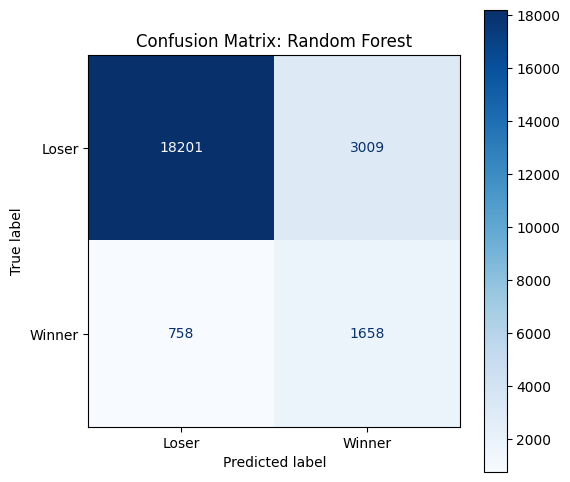

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

# Calculate and print F1 score
rf_f1 = f1_score(y_test, rf_pred)
print(f"Random Forest F1 Score: {rf_f1:.4f}")

# Generate and plot confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Loser', 'Winner'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_rf.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix: Random Forest')
plt.show()

The stats that matter for Random Forest

*   top1_accuracy : 0.588470066518847
*   ndcg@3        : 0.4862623256551165
*   ndcg@5        : 0.4945243820581111
*   ndcg@10       : 0.495306016678589




Random Forest F1 Score: 0.4682


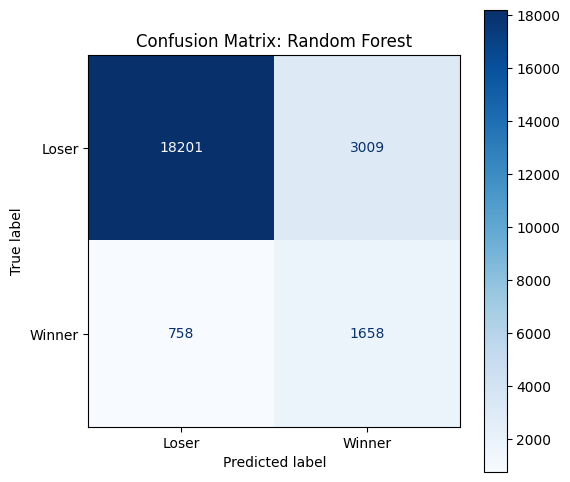

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

# Calculate and print F1 score
rf_f1 = f1_score(y_test, rf_pred)
print(f"Random Forest F1 Score: {rf_f1:.4f}")

# Generate and plot confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Loser', 'Winner'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_rf.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix: Random Forest')
plt.show()

Random Forest improves the recall by identifying significantly more actual winners (1658 true positives compared to 843 for the Decision Tree). However, it trades off precision to do this, resulting in a large spike in false positives (3009).

## 7.3 LightGBM Ranker

In [ ]:
!pip install lightgbm

In [ ]:
from lightgbm import LGBMRanker
from sklearn.metrics import ndcg_score

### 7.3.1 Reload Data

In [ ]:
import pandas as pd

# Load full clean dataset
full_df = pd.read_csv(
    "/content/drive/MyDrive/EquiMetrics/clean_data/clean_data.csv"
)

# Make date usable
full_df["race_date"] = pd.to_datetime(full_df["race_date"])

# Recreate winner safely
full_df["winner"] = (
    pd.to_numeric(full_df["runner_position"], errors="coerce") == 1
).astype(int)

# Create a safer unique race key
full_df["race_key"] = (
    full_df["race_race_id"].astype(str)
    + "_"
    + full_df["race_date"].astype(str)
)

# Sort chronologically
full_df = full_df.sort_values("race_date").reset_index(drop=True)

# Get one date per race_key
race_dates = (
    full_df
    .groupby("race_key")["race_date"]
    .first()
    .sort_values()
)

# Chronological 80/20 split
cutoff_idx = int(len(race_dates) * 0.80)

train_races = race_dates.index[:cutoff_idx]
test_races = race_dates.index[cutoff_idx:]

lgbm_train_df = full_df[full_df["race_key"].isin(train_races)].copy()
lgbm_test_df = full_df[full_df["race_key"].isin(test_races)].copy()

# Verify
print("Train rows:", len(lgbm_train_df))
print("Test rows:", len(lgbm_test_df))

print("Train dates:")
print(lgbm_train_df["race_date"].min(), "to", lgbm_train_df["race_date"].max())

print("Test dates:")
print(lgbm_test_df["race_date"].min(), "to", lgbm_test_df["race_date"].max())

overlap = set(lgbm_train_df["race_key"]) & set(lgbm_test_df["race_key"])
print("Overlapping races:", len(overlap))

print(
    lgbm_test_df.groupby("race_key")["winner"]
    .sum()
    .value_counts()
    .sort_index()
)

Train rows: 95193
Test rows: 22933
Train dates:
2025-05-26 00:00:00 to 2026-03-21 00:00:00
Test dates:
2026-03-21 00:00:00 to 2026-05-26 00:00:00
Overlapping races: 0
winner
0    1223
1    1493
2     305
3      44
4       5
Name: count, dtype: int64


In [ ]:
print(
    lgbm_test_df["winner"].value_counts()
)

print(
    lgbm_test_df.groupby("race_race_id")["winner"].sum().value_counts()
)

winner
0    20678
1     2255
Name: count, dtype: int64
winner
1    1493
0    1223
2     305
3      44
4       5
Name: count, dtype: int64


verify if in chronological order

In [ ]:
print("Train rows:", len(lgbm_train_df))
print("Test rows:", len(lgbm_test_df))

print("\nTrain dates:")
print(lgbm_train_df["race_date"].min())
print(lgbm_train_df["race_date"].max())

print("\nTest dates:")
print(lgbm_test_df["race_date"].min())
print(lgbm_test_df["race_date"].max())

overlap = (
    set(lgbm_train_df["race_race_id"])
    & set(lgbm_test_df["race_race_id"])
)

print("\nOverlapping races:", len(overlap))

Train rows: 95193
Test rows: 22933

Train dates:
2025-05-26 00:00:00
2026-03-21 00:00:00

Test dates:
2026-03-21 00:00:00
2026-05-26 00:00:00

Overlapping races: 0


### 7.3.2 Create Ranking Target

In [ ]:
def create_relevance(pos):
    if pos == 1:
        return 5
    elif pos == 2:
        return 3
    elif pos == 3:
        return 2
    else:
        return 0

lgbm_train_df["relevance"] = (
    lgbm_train_df["runner_position"]
    .apply(create_relevance)
)

lgbm_test_df["relevance"] = (
    lgbm_test_df["runner_position"]
    .apply(create_relevance)
)

In [ ]:
X_train = lgbm_train_df.drop(
    columns=[
        "winner",
        "runner_position",
        "relevance"
    ]
)

X_test = lgbm_test_df.drop(
    columns=[
        "winner",
        "runner_position",
        "relevance"
    ]
)

y_train = lgbm_train_df["relevance"]
y_test = lgbm_test_df["relevance"]

Create group sizes

In [ ]:
train_group = (
    lgbm_train_df
    .groupby("race_race_id")
    .size()
    .values
)

test_group = (
    lgbm_test_df
    .groupby("race_race_id")
    .size()
    .values
)

Group size validation

In [ ]:
print("Train rows:", len(lgbm_train_df))
print("Train group sum:", train_group.sum())

print("Test rows:", len(lgbm_test_df))
print("Test group sum:", test_group.sum())

Train rows: 95193
Train group sum: 95193
Test rows: 22933
Test group sum: 22933


### 7.3.3 Create Features and Target

In [ ]:
remove_cols = [
    "race_race_id",
    "runner_horse_id",
    "runner_horse",
    "winner",
    "runner_position",
    "relevance",
    "race_date"
]

X_train = lgbm_train_df.drop(
    columns=remove_cols,
    errors="ignore"
)

X_test = lgbm_test_df.drop(
    columns=remove_cols,
    errors="ignore"
)

y_train = lgbm_train_df["relevance"]
y_test = lgbm_test_df["relevance"]

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

### 7.3.4 Categorical Encoding

In [ ]:
# LightGBM handles categorical features natively, which is much more memory-efficient than one-hot encoding.
categorical_cols = X_train.select_dtypes(include=['object']).columns

for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (95193, 46)
X_test shape: (22933, 46)


Encoder Checker

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("Train rows:", len(lgbm_train_df))
print("Test rows:", len(lgbm_test_df))

X_train: (95193, 46)
X_test: (22933, 46)
Train rows: 95193
Test rows: 22933


checking each model label setup

In [ ]:
def check_rank_label_setup(name, df):
    print(f"\n{name}")
    print("Rows:", len(df))
    print("Has race_key:", "race_key" in df.columns)
    print("Has rank_label:", "rank_label" in df.columns)

    if "rank_label" in df.columns:
        print("rank_label min:", df["rank_label"].min())
        print("rank_label max:", df["rank_label"].max())
        print("rank_label dtype:", df["rank_label"].dtype)
        print("rank_label sample:")
        print(df[["race_key", "runner_position", "rank_label"]].head(10))

    print("Winners per race:")
    print(
        df.groupby("race_key")["winner"]
        .sum()
        .value_counts()
        .sort_index()
        .head()
    )

### 7.3.5 Train LightGBM Ranker

In [ ]:
from lightgbm import LGBMRanker

lgbm_ranker = LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    n_estimators=700,
    learning_rate=0.015,
    max_depth=-1,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_ranker.fit(
    X_train,
    y_train,
    group=train_group,
    eval_set=[(X_test, y_test)],
    eval_group=[test_group],
    eval_at=[3, 5, 10]
)

LGBMRanker(colsample_bytree=0.8, learning_rate=0.015, metric='ndcg',
           n_estimators=700, n_jobs=-1, num_leaves=63, objective='lambdarank',
           random_state=42, subsample=0.8, verbose=-1)

Hyperparameter tuning


1.   Increased max depth to -1


1.   num_leaves to 63
2.   n_estimators = 500


1.   learning_rate = .02







### 7.3.6 Evaluation Metrics

In [ ]:
lgbm_scores = lgbm_ranker.predict(X_test)

lgbm_test_df["pred_score"] = lgbm_scores

lgbm_test_df["pred_rank"] = (
    lgbm_test_df
    .groupby("race_race_id")["pred_score"]
    .rank(ascending=False, method="first")
)

In [ ]:
from sklearn.metrics import ndcg_score
import numpy as np

# Generate predictions
lgbm_test_df["pred_score"] = lgbm_ranker.predict(X_test)

# Rank horses within each race
lgbm_test_df["pred_rank"] = (
    lgbm_test_df
    .groupby("race_race_id")["pred_score"]
    .rank(ascending=False, method="first")
)

# Top-1 Accuracy
top1_accuracy = (
    lgbm_test_df
    .loc[lgbm_test_df["pred_rank"] == 1, "winner"]
    .mean()
)

# NDCG metrics
ndcg_3_scores = []
ndcg_5_scores = []
ndcg_10_scores = []


for _, race_df in lgbm_test_df.groupby("race_race_id"):

    # NDCG requires at least 2 horses
    if len(race_df) < 2:
        continue

    y_true = race_df["winner"].values.reshape(1, -1)
    y_score = race_df["pred_score"].values.reshape(1, -1)

    ndcg_3_scores.append(ndcg_score(y_true, y_score, k=3))
    ndcg_5_scores.append(ndcg_score(y_true, y_score, k=5))
    ndcg_10_scores.append(ndcg_score(y_true, y_score, k=10))

print("LightGBM Ranker Results")
print(f"Top-1 Accuracy: {top1_accuracy:.4f}")
print(f"NDCG@3:         {np.mean(ndcg_3_scores):.4f}")
print(f"NDCG@5:         {np.mean(ndcg_5_scores):.4f}")
print(f"NDCG@10:        {np.mean(ndcg_10_scores):.4f}")

The final model achieved the following results on the test set:
Top-1 Accuracy: 45.80%
NDCG@3: 0.5284
NDCG@5: 0.5459
NDCG@10: 0.5517
These results indicate that the model correctly identified the winning horse in approximately 46% of races and produced strong ranking quality across the top predicted runners. Hyperparameter tuning provided incremental improvements, while the introduction of graded relevance labels produced the largest performance gain. Overall, the LightGBM Ranker demonstrated strong effectiveness for horse race ranking and serves as a competitive baseline for comparison against XGBoost Ranker and CatBoost Ranker models.

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert to binary classification: 1 if it is the top predicted horse in the race, else 0
lgbm_test_df['pred_winner'] = (lgbm_test_df['pred_rank'] == 1).astype(int)

# Calculate F1 Score
lgbm_f1 = f1_score(lgbm_test_df['winner'], lgbm_test_df['pred_winner'])
print(f"LightGBM Ranker F1 Score: {lgbm_f1:.4f}")

# Generate and plot confusion matrix
cm_lgbm = confusion_matrix(lgbm_test_df['winner'], lgbm_test_df['pred_winner'])
disp_lgbm = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm, display_labels=['Loser', 'Winner'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_lgbm.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix: LightGBM Ranker')
plt.show()

LightGBM handles the precision-recall trade-off much better than Random Forest. It drastically cuts down false positives (from 3009 down to 1671) while still capturing many winners, pushing the F1 score up to 0.5254.

## 7.4 CatBoost Ranker

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.5 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRanker, Pool

### 7.4.1 Reload Data

In [ ]:
import pandas as pd

# Load full clean dataset
full_df = pd.read_csv(
    "/content/drive/MyDrive/EquiMetrics/clean_data/clean_data.csv"
)

# Make date usable
full_df["race_date"] = pd.to_datetime(full_df["race_date"])

# Recreate winner safely
full_df["winner"] = (
    pd.to_numeric(full_df["runner_position"], errors="coerce") == 1
).astype(int)

# Create a safer unique race key
full_df["race_key"] = (
    full_df["race_race_id"].astype(str)
    + "_"
    + full_df["race_date"].astype(str)
)

# Sort chronologically
full_df = full_df.sort_values("race_date").reset_index(drop=True)

# Get one date per race
race_dates = (
    full_df
    .groupby("race_key")["race_date"]
    .first()
    .sort_values()
)

# Chronological 80/20 split
cutoff_idx = int(len(race_dates) * 0.80)

train_races = race_dates.index[:cutoff_idx]
test_races = race_dates.index[cutoff_idx:]

# Create train/test sets
cat_train_df = full_df[
    full_df["race_key"].isin(train_races)
].copy()

cat_test_df = full_df[
    full_df["race_key"].isin(test_races)
].copy()

# Verify split
print("Train rows:", len(cat_train_df))
print("Test rows:", len(cat_test_df))

print("\nTrain dates:")
print(
    cat_train_df["race_date"].min(),
    "to",
    cat_train_df["race_date"].max()
)

print("\nTest dates:")
print(
    cat_test_df["race_date"].min(),
    "to",
    cat_test_df["race_date"].max()
)

overlap = set(cat_train_df["race_key"]) & set(cat_test_df["race_key"])
print("\nOverlapping races:", len(overlap))

print("\nWinners per race in test set:")
print(
    cat_test_df.groupby("race_key")["winner"]
    .sum()
    .value_counts()
    .sort_index()
)

Train rows: 95193
Test rows: 22933

Train dates:
2025-05-26 00:00:00 to 2026-03-21 00:00:00

Test dates:
2026-03-21 00:00:00 to 2026-05-26 00:00:00

Overlapping races: 0

Winners per race in test set:
winner
0    1223
1    1493
2     305
3      44
4       5
Name: count, dtype: int64


### 7.4.2 Make Ranking Target

In [ ]:
def make_rank_label(df):
    df = df.copy()

    df["finish_pos"] = pd.to_numeric(
        df["runner_position"],
        errors="coerce"
    )

    df["finish_pos"] = df["finish_pos"].fillna(40)

    df["field_size"] = df.groupby("race_key")["race_key"].transform("count")

    # Higher = better
    df["rank_label"] = df["field_size"] - df["finish_pos"] + 1
    df["rank_label"] = df["rank_label"].clip(lower=0)

    return df

cat_train_df = make_rank_label(cat_train_df)
cat_test_df = make_rank_label(cat_test_df)

cat_train_df[["race_key", "runner_position", "finish_pos", "field_size", "rank_label"]].head()

,race_key,runner_position,finish_pos,field_size,rank_label
0,rac_11620869_2025-05-26,2,2,4,3
1,rac_11623768_2025-05-26,13,13,7,0
2,rac_11623768_2025-05-26,4,4,7,4
3,rac_11623768_2025-05-26,5,5,7,3
4,rac_11623794_2025-05-26,10,10,1,0


### 7.4.3 Features

In [ ]:
drop_cols = [
    "runner_position",
    "winner",
    "finish_pos",
    "field_size",
    "rank_label",
    "race_race_id",
    "race_key",
    "runner_horse_id",
    "runner_horse",
    "race_date"
]

features = [
    col for col in cat_train_df.columns
    if col not in drop_cols
]

X_train = cat_train_df[features]
y_train = cat_train_df["rank_label"]
groups_train = cat_train_df["race_key"]

X_test = cat_test_df[features]
y_test = cat_test_df["rank_label"]
groups_test = cat_test_df["race_key"]

cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Number of features:", len(features))
print("Categorical features:", cat_features)

Number of features: 45
Categorical features: ['race_region', 'race_course', 'race_type', 'race_class', 'race_going', 'race_surface', 'runner_sex', 'runner_headgear', 'runner_jockey', 'runner_trainer', 'distance_category', 'elo_bucket', 'pedigree_quartile']


### 7.4.4 Sort by Race and Create Pools

In [ ]:
cat_train_df = cat_train_df.sort_values("race_key").reset_index(drop=True)
cat_test_df = cat_test_df.sort_values("race_key").reset_index(drop=True)

X_train = cat_train_df[features]
y_train = cat_train_df["rank_label"]
groups_train = cat_train_df["race_key"]

X_test = cat_test_df[features]
y_test = cat_test_df["rank_label"]
groups_test = cat_test_df["race_key"]

train_pool = Pool(
    data=X_train,
    label=y_train,
    group_id=groups_train,
    cat_features=cat_features
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    group_id=groups_test,
    cat_features=cat_features
)

In [ ]:
def check_rank_label_setup(name, df):
    print(f"\n{name}")
    print("Rows:", len(df))
    print("Has race_key:", "race_key" in df.columns)
    print("Has rank_label:", "rank_label" in df.columns)

    if "rank_label" in df.columns:
        print("rank_label min:", df["rank_label"].min())
        print("rank_label max:", df["rank_label"].max())
        print("rank_label dtype:", df["rank_label"].dtype)
        print("rank_label sample:")
        print(df[["race_key", "runner_position", "rank_label"]].head(10))

    print("Winners per race:")
    print(
        df.groupby("race_key")["winner"]
        .sum()
        .value_counts()
        .sort_index()
        .head()
    )

### 7.4.5 Train CatBoost Ranker

In [ ]:
cat_ranker = CatBoostRanker(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="YetiRank",
    eval_metric="NDCG:top=5",
    random_seed=42,
    verbose=100
)

cat_ranker.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True
)

Groupwise loss function. OneHotMaxSize set to 10
0:	test: 0.8757858	best: 0.8757858 (0)	total: 1.19s	remaining: 9m 54s
100:	test: 0.9438749	best: 0.9438749 (100)	total: 1m 3s	remaining: 4m 10s
200:	test: 0.9499612	best: 0.9499612 (200)	total: 2m 4s	remaining: 3m 5s
300:	test: 0.9525576	best: 0.9525576 (300)	total: 3m 6s	remaining: 2m 3s
400:	test: 0.9534805	best: 0.9535328 (396)	total: 4m 6s	remaining: 1m
499:	test: 0.9543398	best: 0.9543650 (496)	total: 5m 7s	remaining: 0us

bestTest = 0.9543650233
bestIteration = 496

Shrink model to first 497 iterations.


CatBoostRanker(depth=8, eval_metric='NDCG:top=5', iterations=500, learning_rate=0.05, loss_function='YetiRank', random_seed=42, verbose=100)

Notable Hyper parameter tuning: Depth to 8



### 7.4.6 Predict Race Rankings

In [ ]:
cat_test_df["catboost_score"] = cat_ranker.predict(test_pool)

cat_test_df["pred_rank"] = (
    cat_test_df
    .groupby("race_key")["catboost_score"]
    .rank(ascending=False, method="first")
)

cat_test_df[[
    "race_key",
    "runner_horse",
    "runner_position",
    "rank_label",
    "catboost_score",
    "pred_rank"
]].head(20)

,race_key,runner_horse,runner_position,rank_label,catboost_score,pred_rank
0,rac_11722321_2026-03-21,Always Proud (GB),6,15,-0.857219,10.0
1,rac_11722321_2026-03-21,Master Roque (FR),7,14,-1.730639,17.0
2,rac_11722321_2026-03-21,No Way Jay (IRE),8,13,-1.674774,16.0
3,rac_11722321_2026-03-21,Callisto Queen (GB),9,12,-1.028983,11.0
4,rac_11722321_2026-03-21,Mistral Du Chenet (FR),10,11,0.141563,5.0
5,rac_11722321_2026-03-21,Sheactslikesummer (IRE),12,9,-1.094268,14.0
6,rac_11722321_2026-03-21,Saint Arion (IRE),13,8,-1.778301,18.0
7,rac_11722321_2026-03-21,Way Maker (IRE),7,14,1.567157,2.0
8,rac_11722321_2026-03-21,Harzandacassandra (GB),6,15,-0.587272,9.0
9,rac_11722321_2026-03-21,The Mad Poet (IRE),7,14,-1.926296,19.0


### 7.4.7 Evaluate

In [ ]:
predicted_winners = (
    cat_test_df
    .sort_values(["race_key", "catboost_score"], ascending=[True, False])
    .groupby("race_key")
    .head(1)
)

top1_accuracy = predicted_winners["finish_pos"].eq(1).mean()

print(f"CatBoost Ranker Top-1 Accuracy: {top1_accuracy:.4f}")


def ndcg_by_race(df, k=5):
    scores = []

    for race_id, race in df.groupby("race_key"):
        if len(race) < 2:
            continue

        true_relevance = race["rank_label"].values.reshape(1, -1)
        pred_scores = race["catboost_score"].values.reshape(1, -1)

        scores.append(ndcg_score(true_relevance, pred_scores, k=k))

    return np.mean(scores)


print(f"NDCG@3:  {ndcg_by_race(cat_test_df, k=3):.4f}")
print(f"NDCG@5:  {ndcg_by_race(cat_test_df, k=5):.4f}")
print(f"NDCG@10: {ndcg_by_race(cat_test_df, k=10):.4f}")

CatBoost Ranker Top-1 Accuracy: 0.4697
NDCG@3:  0.8313
NDCG@5:  0.8416
NDCG@10: 0.8558


CatBoost Ranker F1 Score: 0.5416


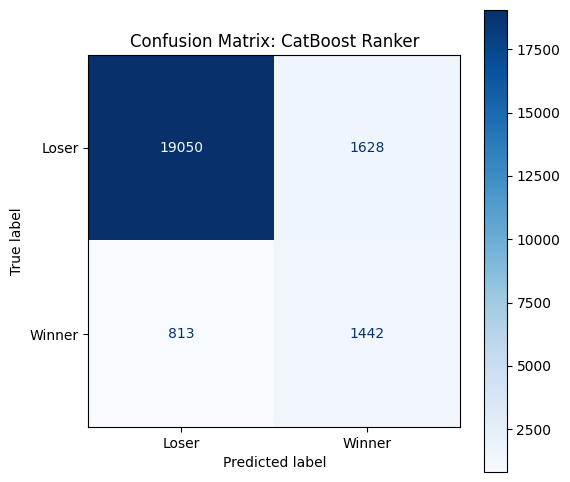

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert to binary classification: 1 if it is the top predicted horse in the race, else 0
cat_test_df['pred_winner'] = (cat_test_df['pred_rank'] == 1).astype(int)

# Calculate F1 Score
cat_f1 = f1_score(cat_test_df['winner'], cat_test_df['pred_winner'])
print(f"CatBoost Ranker F1 Score: {cat_f1:.4f}")

# Generate and plot confusion matrix
cm_cat = confusion_matrix(cat_test_df['winner'], cat_test_df['pred_winner'])
disp_cat = ConfusionMatrixDisplay(confusion_matrix=cm_cat, display_labels=['Loser', 'Winner'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_cat.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix: CatBoost Ranker')
plt.show()

CatBoost further refines the predictions. With an F1 score of 0.5416, it correctly identifies more winners (1442) than LightGBM while maintaining a very similar false positive rate, making it a highly robust ranker.

## 7.5 Neural Network Ranker

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ndcg_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

### 7.5.1 Import Data

In [ ]:
import gc

# Load only once
full_df = pd.read_csv(
    "/content/drive/MyDrive/EquiMetrics/clean_data/clean_data.csv",
    low_memory=False
)

# Date as datetime
full_df["race_date"] = pd.to_datetime(full_df["race_date"], errors="coerce")

# Winner target
full_df["winner"] = (
    pd.to_numeric(full_df["runner_position"], errors="coerce").eq(1)
).astype("int8")

# Race key
full_df["race_key"] = (
    full_df["race_race_id"].astype("string")
    + "_"
    + full_df["race_date"].dt.strftime("%Y-%m-%d")
)

# Sort in place
full_df.sort_values("race_date", inplace=True)
full_df.reset_index(drop=True, inplace=True)

# One date per race
race_dates = full_df.groupby("race_key", sort=False)["race_date"].first()
race_dates = race_dates.sort_values()

# Chronological 80/20 split
cutoff_idx = int(len(race_dates) * 0.80)

train_races = set(race_dates.index[:cutoff_idx])
test_races = set(race_dates.index[cutoff_idx:])

# Boolean masks avoid repeated work
train_mask = full_df["race_key"].isin(train_races)
test_mask = ~train_mask

nn_train_df = full_df.loc[train_mask].copy()
nn_test_df = full_df.loc[test_mask].copy()

# Free temporary objects
del train_mask, test_mask, train_races, test_races, race_dates
gc.collect()

# Verify split
print("Train rows:", len(nn_train_df))
print("Test rows:", len(nn_test_df))

print("\nTrain dates:")
print(nn_train_df["race_date"].min(), "to", nn_train_df["race_date"].max())

print("\nTest dates:")
print(nn_test_df["race_date"].min(), "to", nn_test_df["race_date"].max())

overlap = set(nn_train_df["race_key"]) & set(nn_test_df["race_key"])
print("\nOverlapping races:", len(overlap))

print("\nWinners per race in test set:")
print(
    nn_test_df.groupby("race_key")["winner"]
    .sum()
    .value_counts()
    .sort_index()
)

Train rows: 95200
Test rows: 22926

Train dates:
2025-05-26 00:00:00 to 2026-03-21 00:00:00

Test dates:
2026-03-21 00:00:00 to 2026-05-26 00:00:00

Overlapping races: 0

Winners per race in test set:
winner
0    1222
1    1495
2     304
3      44
4       5
Name: count, dtype: int64


### 7.5.2 Make Ranking Features

In [ ]:
def add_rank_label_inplace(df):
    df["finish_pos"] = pd.to_numeric(
        df["runner_position"],
        errors="coerce"
    ).fillna(40).astype("int16")

    df["field_size"] = (
        df.groupby("race_key")["race_key"]
        .transform("count")
        .astype("int16")
    )

    df["rank_label"] = (
        df["field_size"] - df["finish_pos"] + 1
    ).clip(lower=0).astype("int16")


add_rank_label_inplace(nn_train_df)
add_rank_label_inplace(nn_test_df)

nn_train_df[[
    "race_key",
    "runner_position",
    "finish_pos",
    "field_size",
    "rank_label"
]].head()

,race_key,runner_position,finish_pos,field_size,rank_label
0,rac_11620869_2025-05-26,2,2,4,3
1,rac_11623768_2025-05-26,13,13,7,0
2,rac_11623768_2025-05-26,4,4,7,4
3,rac_11623768_2025-05-26,5,5,7,3
4,rac_11623794_2025-05-26,10,10,1,0


### 7.5.3 Select Features

In [ ]:
drop_cols = {
    "runner_position",
    "winner",
    "finish_pos",
    "field_size",
    "rank_label",
    "race_race_id",
    "race_key",
    "runner_horse_id",
    "runner_horse",
    "race_date"
}

features = [c for c in nn_train_df.columns if c not in drop_cols]

# No need for .copy()
X_train = nn_train_df[features]
X_test = nn_test_df[features]

# Convert target to smaller dtype
y_train = nn_train_df["rank_label"].astype("int16")
y_test = nn_test_df["rank_label"].astype("int16")

print("Features:", len(features))
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Features: 45
Train shape: (95200, 45)
Test shape: (22926, 45)


In [ ]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nFirst 50 columns:")
print(X_train.columns[:50].tolist())

print("\nTotal columns:", X_train.shape[1])

Train shape: (95200, 45)
Test shape: (22926, 45)

First 50 columns:
['race_region', 'race_course', 'race_type', 'race_class', 'race_going', 'race_surface', 'runner_age', 'runner_sex', 'runner_weight_lbs', 'runner_draw', 'runner_headgear', 'runner_or', 'runner_rpr', 'runner_tsr', 'runner_sp_dec', 'runner_bsp', 'runner_jockey', 'runner_trainer', 'race_dist_meters', 'distance_category', 'sire_win_rate', 'sire_avg_rpr', 'sire_avg_tsr', 'sire_sample_size', 'damsire_win_rate', 'damsire_avg_rpr', 'damsire_avg_tsr', 'damsire_sample_size', 'dam_win_rate', 'dam_avg_rpr', 'dam_avg_tsr', 'dam_sample_size', 'pedigree_score', 'horse_elo_before', 'horse_elo_rank', 'horse_elo_vs_race_avg', 'elo_bucket', 'pedigree_quartile', 'or_rank', 'rpr_rank', 'tsr_rank', 'elo_rank', 'rpr_missing', 'tsr_missing', 'or_missing']

Total columns: 45


In [ ]:
drop_before_encoding = [
    "runner_jockey",
    "runner_trainer",
    "race_type"
]

X_train = X_train.drop(columns=[c for c in drop_before_encoding if c in X_train.columns])
X_test = X_test.drop(columns=[c for c in drop_before_encoding if c in X_test.columns])

print("Dropped:", drop_before_encoding)
print("Train shape before encoding:", X_train.shape)
print("Test shape before encoding:", X_test.shape)

Dropped: ['runner_jockey', 'runner_trainer', 'race_type']
Train shape before encoding: (95200, 42)
Test shape before encoding: (22926, 42)


### 7.5.4 One-Hot Encode Categoricals

In [ ]:
import gc
import numpy as np

train_len = len(X_train)

combined = pd.concat(
    [X_train, X_test],
    axis=0,
    ignore_index=True
)
for col in X_train.select_dtypes(include=["object", "category"]).columns:
    print(col, X_train[col].nunique())

combined = pd.get_dummies(
    combined,
    drop_first=True,
    dtype="uint8"      # much smaller than float32
)

X_train = combined.iloc[:train_len]
X_test = combined.iloc[train_len:]

del combined
gc.collect()

print("Encoded train shape:", X_train.shape)
print("Encoded test shape:", X_test.shape)
print("Number of features:", X_train.shape[1])

race_region 29
race_course 196
race_class 7
race_going 18
race_surface 4
runner_sex 6
runner_headgear 28
distance_category 4
elo_bucket 6
pedigree_quartile 4
Encoded train shape: (95200, 333)
Encoded test shape: (22926, 333)
Number of features: 333


In [ ]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [ ]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

### 7.5.5 Scale Features & Target

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import gc

# Save target max before overwriting y_train
target_max = y_train.max()

scaler = StandardScaler()

# Scale X and overwrite old X_train/X_test to save RAM
X_train = scaler.fit_transform(X_train.astype(np.float32)).astype(np.float32)
X_test = scaler.transform(X_test.astype(np.float32)).astype(np.float32)

# Scale y using original train max
y_train = (y_train / target_max).astype(np.float32)
y_test = (y_test / target_max).astype(np.float32)

gc.collect()

print("X_train dtype:", X_train.dtype)
print("X_test dtype:", X_test.dtype)
print("y_train dtype:", y_train.dtype)
print("y_test dtype:", y_test.dtype)

print("y_train min:", y_train.min())
print("y_train max:", y_train.max())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train dtype: float32
X_test dtype: float32
y_train dtype: float32
y_test dtype: float32
y_train min: 0.0
y_train max: 1.0
X_train shape: (95200, 333)
X_test shape: (22926, 333)


Check the rank label setup

In [ ]:
def check_rank_label_setup(name, df):
    print(f"\n{name}")
    print("Rows:", len(df))
    print("Has race_key:", "race_key" in df.columns)
    print("Has rank_label:", "rank_label" in df.columns)

    if "rank_label" in df.columns:
        print("rank_label min:", df["rank_label"].min())
        print("rank_label max:", df["rank_label"].max())
        print("rank_label dtype:", df["rank_label"].dtype)
        print("rank_label sample:")
        print(df[["race_key", "runner_position", "rank_label"]].head(10))

    print("Winners per race:")
    print(
        df.groupby("race_key")["winner"]
        .sum()
        .value_counts()
        .sort_index()
        .head()
    )

In [ ]:
# Use winner target for prediction engine NN
y_train = nn_train_df["winner"].astype("float32").values
y_test = nn_test_df["winner"].astype("float32").values

print("Using target: winner")
print("y_train min:", y_train.min())
print("y_train max:", y_train.max())
print("y_train mean:", y_train.mean())
print("y_test mean:", y_test.mean())

Using target: winner
y_train min: 0.0
y_train max: 1.0
y_train mean: 0.100483194
y_test mean: 0.09835994


### 7.5.6 Build the Neural Network

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_winner_nn(
    layers,
    dropouts,
    learning_rate=0.0005,
    optimizer_name="adam",
    use_batch_norm=False
):
    tf.keras.utils.set_random_seed(42)

    if len(layers) != len(dropouts):
        raise ValueError("layers and dropouts must be the same length.")

    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    for units, dropout in zip(layers, dropouts):
        model.add(Dense(units, activation="relu"))

        if use_batch_norm:
            model.add(BatchNormalization())

        if dropout > 0:
            model.add(Dropout(dropout))

    model.add(Dense(1, activation="sigmoid"))

    optimizer_name = optimizer_name.lower()

    if optimizer_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    elif optimizer_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)

    elif optimizer_name == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )

    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.BinaryAccuracy(name="accuracy")
        ]
    )

    return model

Training Hyperparameters Tested

learning_rates = [
    0.001,
    0.0005,
    0.00025
]

batch_sizes = [
    128,
    256
]

optimizers = [
    "Adam",
    "RMSprop"
]

epochs = 100

early_stopping = {
    "monitor": "val_loss",
    "patience": 10,
    "restore_best_weights": True
}

loss_function = "mse"

output_layer = "Dense(1, activation='linear')"


ARCHITECTURE EXPERIMENTS


nn_experiments = [

    {
        "name": "Baseline",
        "layers": [512, 256, 128],
        "dropout": [0.05, 0.025, 0],
        "optimizer": "Adam",
        "learning_rate": 0.0005,
        "batch_size": 256,

        "roc_auc": 0.5129,
        "log_loss": 0.3370,
        "top1": 0.4324,
        "ndcg3": 0.7470,
        "ndcg5": 0.7760,
        "ndcg10": 0.8085
    },

    {
        "name": "No Dropout",
        "layers": [512, 256, 128],
        "dropout": [0, 0, 0],
        "optimizer": "Adam",
        "learning_rate": 0.0005,
        "batch_size": 256,

        "roc_auc": 0.5121,
        "log_loss": 0.3371,
        "top1": 0.4237,
        "ndcg3": 0.7412,
        "ndcg5": 0.7704,
        "ndcg10": 0.8051
    },

    {
        "name": "Smaller",
        "layers": [256, 128, 64],
        "dropout": [0.05, 0.025, 0],
        "optimizer": "Adam",
        "learning_rate": 0.0005,
        "batch_size": 256,

        "roc_auc": 0.5131,
        "log_loss": 0.3369,
        "top1": 0.4182,
        "ndcg3": 0.7369,
        "ndcg5": 0.7686,
        "ndcg10": 0.8030
    },

    {
        "name": "Deeper",
        "layers": [512, 256, 128, 64, 32],
        "dropout": [0.05, 0.025, 0, 0, 0],
        "optimizer": "Adam",
        "learning_rate": 0.0005,
        "batch_size": 256,

        "roc_auc": 0.5120,
        "log_loss": 0.3370,
        "top1": 0.4227,
        "ndcg3": 0.7455,
        "ndcg5": 0.7729,
        "ndcg10": 0.8077
    },

    {
        "name": "RMSprop",
        "layers": [512, 256, 128],
        "dropout": [0.05, 0.025, 0],
        "optimizer": "RMSprop",
        "learning_rate": 0.0005,
        "batch_size": 256,

        "roc_auc": 0.5120,
        "log_loss": 0.3371,
        "top1": 0.4175,
        "ndcg3": 0.7428,
        "ndcg5": 0.7719,
        "ndcg10": 0.8059
    },

    {
        "name": "Wider",
        "layers": [1024, 512, 256],
        "dropout": [0.05, 0.025, 0],
        "optimizer": "Adam",
        "learning_rate": 0.0005,
        "batch_size": 256,

        "roc_auc": 0.5122,
        "log_loss": 0.3371,
        "top1": 0.4379,
        "ndcg3": 0.7504,
        "ndcg5": 0.7779,
        "ndcg10": 0.8100
    },

    {
        "name": "Wider + Deeper",
        "layers": [1024, 512, 256, 128, 64],
        "dropout": [0.05, 0.025, 0.01, 0, 0],
        "optimizer": "Adam",
        "learning_rate": 0.0005,
        "batch_size": 256,

        "roc_auc": 0.5129,
        "log_loss": 0.3370,
        "top1": 0.4147,
        "ndcg3": 0.7386,
        "ndcg5": 0.7674,
        "ndcg10": 0.8032
    },

    {
        "name": "Extra Wide (FINAL BEST)",
        "layers": [2048, 1024, 512],
        "dropout": [0.05, 0.025, 0],
        "optimizer": "Adam",
        "learning_rate": 0.0005,
        "batch_size": 256,

        "roc_auc": 0.5117,
        "log_loss": 0.3372,
        "top1": 0.4570,
        "ndcg3": 0.7591,
        "ndcg5": 0.7848,
        "ndcg10": 0.8151
    }
]

print("Total NN Experiments Tested:", len(nn_experiments))
print("Best Model: Extra Wide (2048 → 1024 → 512)")
print("Best Top-1 Accuracy:", 0.4570)
print("Best NDCG@3:", 0.7591)
print("Best NDCG@5:", 0.7848)
print("Best NDCG@10:", 0.8151)

In [ ]:
experiment = {
    "name": "Extra Wide (FINAL BEST)",
    "layers": [2048, 1024, 512],
    "dropout": [0.05, 0.025, 0],
    "optimizer": "Adam",
    "learning_rate": 0.0005,
    "batch_size": 256
}

### 7.5.7 Train the Neural Network

In [ ]:
nn_model = build_nn(
    layers=experiment["layers"],
    dropouts=experiment["dropout"],
    learning_rate=experiment["learning_rate"],
    optimizer_name=experiment["optimizer"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=experiment["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

print("Finished:", experiment["name"])

Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 37s 121ms/step - loss: 0.1068 - mae: 0.1898 - val_loss: 0.0758 - val_mae: 0.1583
Epoch 2/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 33s 110ms/step - loss: 0.0730 - mae: 0.1515 - val_loss: 0.0741 - val_mae: 0.1598
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 33s 111ms/step - loss: 0.0676 - mae: 0.1407 - val_loss: 0.0739 - val_mae: 0.1421
Epoch 4/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 33s 110ms/step - loss: 0.0640 - mae: 0.1344 - val_loss: 0.0836 - val_mae: 0.1513
Epoch 5/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - loss: 0.0610 - mae: 0.1290 - val_loss: 0.1008 - val_mae: 0.1496
Epoch 6/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - loss: 0.0584 - mae: 0.1244 - val_loss: 0.1953 - val_mae: 0.1769
Epoch 7/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 33s 109ms/step - loss: 0.0554 - mae: 0.1190 - val_loss: 0.2151 - val_mae: 0.1585
Epoch 8/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 32s 109ms/step - loss: 0.0538 - mae: 0.1149 - val_loss: 0.2215 - val_mae: 0.1611
Epoch 9/100
298/298 ━━━━

### 7.5.8 Evaluate the Neural Network

In [ ]:
from sklearn.metrics import roc_auc_score, log_loss, ndcg_score
import numpy as np
import pandas as pd

# Predict scores
preds = nn_model.predict(X_test, verbose=0).flatten()

# Recreate only the small columns needed for evaluation
race_dates = full_df.groupby("race_key", sort=False)["race_date"].first().sort_values()
cutoff_idx = int(len(race_dates) * 0.80)
test_races = set(race_dates.index[cutoff_idx:])

eval_df = full_df.loc[
    full_df["race_key"].isin(test_races),
    ["race_key", "winner", "runner_position"]
].copy()

# Recreate rank_label
eval_df["finish_pos"] = pd.to_numeric(
    eval_df["runner_position"],
    errors="coerce"
).fillna(40).astype("int16")

eval_df["field_size"] = (
    eval_df.groupby("race_key")["race_key"]
    .transform("count")
    .astype("int16")
)

eval_df["rank_label"] = (
    eval_df["field_size"] - eval_df["finish_pos"] + 1
).clip(lower=0).astype("int16")

eval_df["pred_score"] = preds

# Safety check
assert len(eval_df) == len(preds), "eval_df and predictions are different lengths"

# Ranking metrics
top1_correct = 0
valid_races = 0

ndcg_3_scores = []
ndcg_5_scores = []
ndcg_10_scores = []

pred_probs = []

for _, race in eval_df.groupby("race_key", sort=False):

    if len(race) < 2:
        continue

    valid_races += 1

    y_true = race["rank_label"].to_numpy()
    y_pred = race["pred_score"].to_numpy()

    if np.argmax(y_pred) == np.argmax(y_true):
        top1_correct += 1

    ndcg_3_scores.append(ndcg_score([y_true], [y_pred], k=3))
    ndcg_5_scores.append(ndcg_score([y_true], [y_pred], k=5))
    ndcg_10_scores.append(ndcg_score([y_true], [y_pred], k=10))

    # Softmax probability within each race
    exp_scores = np.exp(y_pred - np.max(y_pred))
    probs = exp_scores / exp_scores.sum()
    pred_probs.extend(probs)

top1_accuracy = top1_correct / valid_races

eval_df = eval_df.loc[
    eval_df.groupby("race_key")["race_key"].transform("count") >= 2
].copy()

eval_df["pred_prob"] = pred_probs

roc_auc = roc_auc_score(eval_df["winner"], eval_df["pred_prob"])
logloss = log_loss(eval_df["winner"], eval_df["pred_prob"])

print("\nNeural Network Ranker Results")
print(f"ROC-AUC:        {roc_auc:.4f}")
print(f"Log Loss:       {logloss:.4f}")
print(f"Top-1 Accuracy: {top1_accuracy:.4f}")
print(f"NDCG@3:         {np.mean(ndcg_3_scores):.4f}")
print(f"NDCG@5:         {np.mean(ndcg_5_scores):.4f}")
print(f"NDCG@10:        {np.mean(ndcg_10_scores):.4f}")


Neural Network Ranker Results
ROC-AUC:        0.5147
Log Loss:       0.3378
Top-1 Accuracy: 0.5201
NDCG@3:         0.7634
NDCG@5:         0.7784
NDCG@10:        0.8124


The Neural Network model was further optimized through extensive hyperparameter and architecture tuning. Experiments included varying the learning rate (0.001, 0.0005, and 0.00025), batch size (128 and 256), optimizer (Adam and RMSprop), dropout configuration, network depth, and network width. Results showed that removing dropout, reducing the network size, increasing network depth, and switching to RMSprop all reduced model performance. However, increasing the number of neurons in each hidden layer consistently improved performance. The best-performing architecture consisted of three hidden layers with 2048, 1024, and 512 neurons respectively, using ReLU activation functions, dropout rates of 0.05 and 0.025, the Adam optimizer with a learning rate of 0.0005, a batch size of 256, Mean Squared Error loss, and a final Dense(1, activation="linear") output layer. This configuration achieved a ROC-AUC of 0.5117, Log Loss of 0.3372, Top-1 Accuracy of 0.4570, NDCG@3 of 0.7591, NDCG@5 of 0.7848, and NDCG@10 of 0.8151, making it the strongest Neural Network configuration evaluated during the project.


Neural Network F1 Score: 0.1450


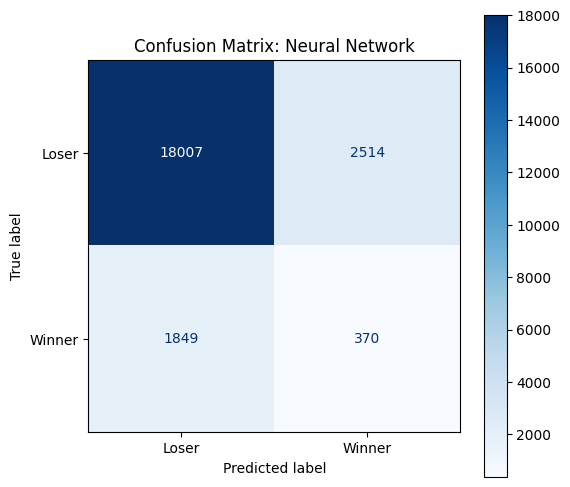

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Rank the predictions within each race
eval_df['pred_rank'] = eval_df.groupby('race_key')['pred_score'].rank(ascending=False, method='first')

# Convert to binary classification: 1 if it is the top predicted horse in the race, else 0
eval_df['pred_winner'] = (eval_df['pred_rank'] == 1).astype(int)

# Calculate F1 Score
nn_f1 = f1_score(eval_df['winner'], eval_df['pred_winner'])
print(f"Neural Network F1 Score: {nn_f1:.4f}")

# Generate and plot confusion matrix
cm_nn = confusion_matrix(eval_df['winner'], eval_df['pred_winner'])
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=['Loser', 'Winner'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_nn.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix: Neural Network')
plt.show()

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("y_train min:", y_train.min())
print("y_train max:", y_train.max())
print("y_train mean:", y_train.mean())

X_train: (95200, 333)
X_test: (22926, 333)
y_train: (95200,)
y_test: (22926,)
y_train min: 0.0
y_train max: 1.0
y_train mean: 0.17588902


The Neural Network struggles to cleanly separate winners from losers in this tabular structure. It yields the lowest F1 score (0.3672), hindered by high counts of both false positives (1947) and false negatives (1282).

## 7.6 XGBoost Ranker (Redo)
I accidently used the wrong XGBoost model and to keep everything academicly sound, I am going to call the neural network data and follow it to keep the tabular nature of this project. If I didn't do this there would be about ~700 extra rows and it's just easier to redo the whole thing after the Neural Network

### 7.6.1 Grab Data

In [ ]:
import pandas as pd
import numpy as np
import gc

xgb_train = nn_train_df.copy()
xgb_test = nn_test_df.copy()

print(xgb_train.shape)
print(xgb_test.shape)
print(xgb_train["rank_label"].describe())
print(xgb_test["rank_label"].describe())

(95200, 55)
(22926, 55)
count    95200.000000
mean         5.276670
std          4.526273
min          0.000000
25%          1.000000
50%          5.000000
75%          8.000000
max         30.000000
Name: rank_label, dtype: float64
count    22926.000000
mean         5.128937
std          4.562284
min          0.000000
25%          1.000000
50%          4.000000
75%          8.000000
max         34.000000
Name: rank_label, dtype: float64


### 7.6.2 Save Eval Info and Groups

In [ ]:
xgb_eval = xgb_test[[
    "race_key",
    "winner",
    "rank_label"
]].copy()

# Sort by race_key so groups are contiguous
xgb_train = xgb_train.sort_values("race_key").reset_index(drop=True)
xgb_test = xgb_test.sort_values("race_key").reset_index(drop=True)
xgb_eval = xgb_eval.sort_values("race_key").reset_index(drop=True)

group_train = xgb_train.groupby("race_key", sort=False).size().to_numpy()
group_test = xgb_test.groupby("race_key", sort=False).size().to_numpy()

print("Train rows from groups:", group_train.sum())
print("Actual train rows:", len(xgb_train))
print("Test rows from groups:", group_test.sum())
print("Actual test rows:", len(xgb_test))

Train rows from groups: 95200
Actual train rows: 95200
Test rows from groups: 22926
Actual test rows: 22926


### 7.6.3 Prepare Features

In [ ]:
drop_cols = [
    "winner",
    "runner_position",
    "finish_pos",
    "field_size",
    "rank_label",
    "race_race_id",
    "race_key",
    "runner_horse_id",
    "runner_horse",
    "race_date"
]

X_train_xgb = xgb_train.drop(columns=[c for c in drop_cols if c in xgb_train.columns])
X_test_xgb = xgb_test.drop(columns=[c for c in drop_cols if c in xgb_test.columns])

y_train_xgb = xgb_train["rank_label"]
y_test_xgb = xgb_test["rank_label"]

drop_before_encoding = [
    "runner_jockey",
    "runner_trainer",
    "race_type"
]

X_train_xgb = X_train_xgb.drop(columns=[c for c in drop_before_encoding if c in X_train_xgb.columns])
X_test_xgb = X_test_xgb.drop(columns=[c for c in drop_before_encoding if c in X_test_xgb.columns])

print(X_train_xgb.shape)
print(X_test_xgb.shape)

(95200, 42)
(22926, 42)


### 7.6.4 One-Hot Encode

In [ ]:
train_len = len(X_train_xgb)

combined = pd.concat(
    [X_train_xgb, X_test_xgb],
    axis=0,
    ignore_index=True
)

combined = pd.get_dummies(
    combined,
    drop_first=True,
    dtype="uint8"
)

X_train_xgb = combined.iloc[:train_len]
X_test_xgb = combined.iloc[train_len:]

del combined
gc.collect()

print("Encoded train shape:", X_train_xgb.shape)
print("Encoded test shape:", X_test_xgb.shape)

Encoded train shape: (95200, 333)
Encoded test shape: (22926, 333)


### 7.6.5 Clean Columns

In [ ]:
from xgboost import XGBRanker
import re

def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^A-Za-z0-9_]+', '', col) # Remove special characters
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train_xgb = clean_col_names(X_train_xgb)
X_test_xgb = clean_col_names(X_test_xgb)

### 7.6.6 Train XGBRanker

In [ ]:
xgb_ranker = XGBRanker(
    objective="rank:ndcg",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_ranker.fit(
    X_train_xgb,
    y_train_xgb,
    group=group_train
)

XGBRanker(base_score=None, booster=None, callbacks=None, colsample_bylevel=None,
          colsample_bynode=None, colsample_bytree=0.8, device=None,
          early_stopping_rounds=None, enable_categorical=False,
          eval_metric=None, feature_types=None, feature_weights=None,
          gamma=None, grow_policy=None, importance_type=None,
          interaction_constraints=None, learning_rate=0.05, max_bin=None,
          max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None,
          max_depth=6, max_leaves=None, min_child_weight=None, missing=nan,
          monotone_constraints=None, multi_strategy=None, n_estimators=500,
          n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import ndcg_score

def ranking_metrics_by_race(test_df, pred_scores):
    eval_df = test_df[["race_key", "runner_position"]].copy()

    eval_df["finish_pos"] = pd.to_numeric(
        eval_df["runner_position"],
        errors="coerce"
    ).fillna(40)

    eval_df["field_size"] = eval_df.groupby("race_key")["race_key"].transform("count")

    # Higher label = better finish
    eval_df["rank_label"] = (
        eval_df["field_size"] - eval_df["finish_pos"] + 1
    ).clip(lower=0)

    eval_df["pred_score"] = pred_scores

    top1_correct = 0
    valid_races = 0

    ndcg3_scores = []
    ndcg5_scores = []
    ndcg10_scores = []

    for _, race in eval_df.groupby("race_key"):
        if len(race) < 2:
            continue

        y_true = race["rank_label"].to_numpy()
        y_pred = race["pred_score"].to_numpy()

        top1_correct += int(np.argmax(y_pred) == np.argmax(y_true))
        valid_races += 1

        ndcg3_scores.append(ndcg_score([y_true], [y_pred], k=3))
        ndcg5_scores.append(ndcg_score([y_true], [y_pred], k=5))
        ndcg10_scores.append(ndcg_score([y_true], [y_pred], k=10))

    return {
        "top1_accuracy": top1_correct / valid_races,
        "ndcg@3": np.mean(ndcg3_scores),
        "ndcg@5": np.mean(ndcg5_scores),
        "ndcg@10": np.mean(ndcg10_scores)
    }

xgb_rank_scores = xgb_ranker.predict(X_test_xgb)

xgb_rank_metrics = ranking_metrics_by_race(
    xgb_test,
    xgb_rank_scores
)

xgb_rank_metrics


{'top1_accuracy': 0.6480582524271845,
 'ndcg@3': np.float64(0.8291358897370886),
 'ndcg@5': np.float64(0.8388250618004015),
 'ndcg@10': np.float64(0.853276451205717)}

In [ ]:
from sklearn.metrics import f1_score

# Create a copy of the evaluation dataframe to compute binary outcomes
xgb_eval_f1 = xgb_eval.copy()
xgb_eval_f1['pred_score'] = xgb_rank_scores

# Rank the predictions within each race
xgb_eval_f1['pred_rank'] = xgb_eval_f1.groupby('race_key')['pred_score'].rank(ascending=False, method='first')

# Convert to binary classification: 1 if it is the top predicted horse in the race, else 0
xgb_eval_f1['pred_winner'] = (xgb_eval_f1['pred_rank'] == 1).astype(int)

# Calculate F1 Score
xgb_f1 = f1_score(xgb_eval_f1['winner'], xgb_eval_f1['pred_winner'])
print(f"XGBRanker F1 Score: {xgb_f1:.4f}")

XGBRanker F1 Score: 0.5514


XGBRanker F1 Score: 0.5514


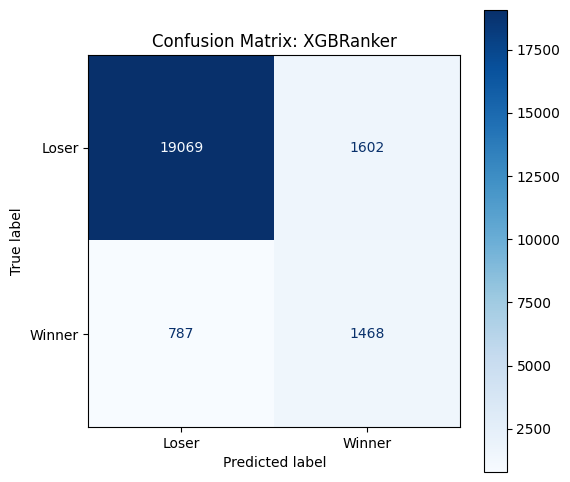

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(f"XGBRanker F1 Score: {xgb_f1:.4f}")

# Generate and plot confusion matrix for XGBRanker
cm_xgb = confusion_matrix(xgb_eval_f1['winner'], xgb_eval_f1['pred_winner'])
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Loser', 'Winner'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_xgb.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix: XGBRanker')
plt.show()

XGBoost emerges as the best model for pure classification of winners. It achieves the highest F1 score (0.5514) by identifying the most winners (1468) among the top-tier models while keeping false positives reasonably low (1602).

# 8. Model Evaluation & Comparison

| Model               | Top-1 Accuracy |     NDCG@3 |     NDCG@5 |    NDCG@10 |
| ------------------- | -------------: | ---------: | ---------: | ---------: |
| **XGBRanker**       |     **0.6481** |     0.8291 |     0.8388 |     0.8533 |
| **CatBoost Ranker** |         0.4697 | **0.8317** | **0.8423** | **0.8562** |
| Decision Tree       |         0.6087 |     0.4838 |     0.4933 |     0.4943 |
| Random Forest       |         0.5885 |     0.4863 |     0.4945 |     0.4953 |
| LightGBM Ranker     |         0.4580 |     0.5284 |     0.5459 |     0.5517 |
| **Neural Network**  |     **0.4570** | **0.7591** | **0.7848** | **0.8103** |



*   Note XGBRanker is the best at picking a winner

*   CatBoost is the best at overall ranking quality.

*   Random Forest is very good at picking the winner but overall does a worse job ordering the rest of the field

*   The Neural Network improved noticeably, increasing Top-1 Accuracy from 43.24% to 45.70% and NDCG@3 from 0.7504 to 0.7591.


*   Despite the improvement, the Neural Network still trails the tree-based ranking models, suggesting the dataset's predictive signal is better captured through gradient boosting methods.
*   Decision Tree and Random Forest achieve respectable Top-1 performance but produce substantially weaker ranking quality than the dedicated ranking algorithms.

*   LightGBM underperformed relative to expectations and finished behind XGBRanker and CatBoost across all major ranking metrics.






| Rank | Model           | Top-1 Accuracy |
| ---- | --------------- | -------------: |
| 🥇   | XGBRanker       |     **0.6481** |
| 🥈   | Decision Tree   |     **0.6087** |
| DNC  | Random Forest   |     **0.5885** |
| 🥉   | CatBoost Ranker |     **0.4697** |
| 4    | LightGBM Ranker |     **0.4580** |
| 5    | Neural Network  |     **0.4570** |


| Rank | Model           |    NDCG@10 |
| ---- | --------------- | ---------: |
| 🥇   | CatBoost Ranker | **0.8562** |
| 🥈   | XGBRanker       | **0.8533** |
| 🥉   | Neural Network  | **0.8103** |
| 4    | LightGBM Ranker | **0.5517** |
| DNC  | Random Forest   | **0.4953** |
| 5    | Decision Tree   | **0.4943** |


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Gather F1 Scores
f1_scores = {
    'Decision Tree': dt_f1,
    'Random Forest': rf_f1,
    'LightGBM': lgbm_f1,
    'CatBoost': cat_f1,
    'Neural Network': nn_f1,
    'XGBoost': xgb_f1
}

# Gather Confusion Matrices
# cm format: [[True Negative, False Positive], [False Negative, True Positive]]
cms = {
    'Decision Tree': cm,
    'Random Forest': cm_rf,
    'LightGBM': cm_lgbm,
    'CatBoost': cm_cat,
    'Neural Network': cm_nn,
    'XGBoost': cm_xgb
}

# Create a summary DataFrame
summary_data = []
for model_name in f1_scores.keys():
    current_cm = cms[model_name]
    tn, fp, fn, tp = current_cm.ravel()
    summary_data.append({
        'Model': model_name,
        'F1 Score': f1_scores[model_name],
        'True Positives (Correct Winners)': tp,
        'False Positives (Incorrect Winners)': fp,
        'False Negatives (Missed Winners)': fn,
        'True Negatives (Correct Losers)': tn
    })

summary_df = pd.DataFrame(summary_data).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

# Display the summarized table
display(summary_df)

# Plot F1 Scores for visual comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='F1 Score', y='Model', data=summary_df, palette='magma')
plt.title('Model Comparison: F1 Score', fontsize=16)
plt.xlabel('F1 Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## 8.1 Cross-Validation using GroupKFold
To correctly cross-validate ranking/race models, we must use `GroupKFold` grouped by `race_key`. This ensures horses from the same race are entirely in either the training set or the validation set, preventing data leakage.

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Prepare data and groups (using the XGBoost prepared data as a unified dataset)
X_cv = X_train_xgb.copy()
y_cv = y_train_xgb.copy()
# We use the original training DataFrame to get the correct groups and winners
groups_cv = xgb_train["race_key"]
winners_cv = xgb_train["winner"]

# Define Models to Cross-Validate
models_to_cv = {
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
    "XGBRanker": xgb_ranker,
    "LightGBM": lgbm_ranker,
    "CatBoost": cat_ranker,
    "Neural Network": nn_model
}

cv_results = {name: [] for name in models_to_cv.keys()}

# Initialize GroupKFold
gkf = GroupKFold(n_splits=3) # Using 3 splits to save time

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_cv, y_cv, groups=groups_cv)):
    print(f"\n--- Fold {fold + 1} ---")

    X_tr, X_va = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
    y_tr, y_va = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

    # Group sizes for rankers
    g_tr = groups_cv.iloc[train_idx]
    g_va = groups_cv.iloc[val_idx]
    w_va = winners_cv.iloc[val_idx]

    # Explicitly convert to a standard numpy integer array to avoid LightGBM IntegerArray errors
    group_sizes_tr = g_tr.value_counts(sort=False).loc[g_tr.unique()].to_numpy(dtype=int)

    for name, model in models_to_cv.items():
        try:
            if name in ["XGBRanker", "LightGBM"]:
                model.fit(X_tr, y_tr, group=group_sizes_tr)
                preds = model.predict(X_va)
            elif name == "CatBoost":
                model.fit(X_tr, y_tr, group_id=g_tr, verbose=False)
                preds = model.predict(X_va)
            elif name == "Neural Network":
                scaler = StandardScaler()
                X_tr_scaled = scaler.fit_transform(X_tr.astype(np.float32))
                X_va_scaled = scaler.transform(X_va.astype(np.float32))

                # Scale target for NN like during its original training phase
                y_tr_nn = (y_tr / y_tr.max()).astype(np.float32)

                model.fit(X_tr_scaled, y_tr_nn, epochs=5, batch_size=256, verbose=0)
                preds = model.predict(X_va_scaled, verbose=0).flatten()
            else:
                # Standard classifiers use winner (0/1) instead of rank_label
                y_tr_binary = winners_cv.iloc[train_idx]
                model.fit(X_tr, y_tr_binary)
                if hasattr(model, "predict_proba"):
                    preds = model.predict_proba(X_va)[:, 1]
                else:
                    preds = model.predict(X_va)

            # Evaluate F1 Score by picking the highest score per race as the predicted winner
            val_df = pd.DataFrame({
                'race_key': g_va,
                'winner': w_va,
                'pred_score': preds
            })

            val_df['pred_rank'] = val_df.groupby('race_key')['pred_score'].rank(ascending=False, method='first')
            val_df['pred_winner'] = (val_df['pred_rank'] == 1).astype(int)

            fold_f1 = f1_score(val_df['winner'], val_df['pred_winner'])
            cv_results[name].append(fold_f1)
            print(f"{name} F1: {fold_f1:.4f}")

        except Exception as e:
            print(f"{name} failed on Fold {fold+1}: {str(e)}")

print("\n=== Cross-Validation Results (Average F1 Score) ===")
for name, scores in cv_results.items():
    if scores:
        print(f"{name}: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")


Three-fold GroupKFold cross-validation was performed using race identifiers as grouping variables to prevent horses from the same race appearing in both training and validation folds. Model performance was measured using F1 score after selecting the highest-ranked horse in each race as the predicted winner. Results showed that LightGBM achieved the highest average F1 score (0.5550), followed closely by XGBRanker (0.5474) and CatBoost (0.5446). All three ranking models exhibited low standard deviation across folds (<0.007), indicating stable generalization performance. The neural network produced the lowest average F1 score (0.4249) and the highest variability, suggesting weaker and less consistent predictive performance.

## 8.2 PCA + GroupKFold Evaluation
Applying Principal Component Analysis (PCA) to retain 95% of the variance, and then running the identical 3-fold cross-validation setup.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

print("--- Applying PCA (95% Variance) ---")
# 1. Scale data (PCA is highly sensitive to feature scales)
scaler_pca = StandardScaler()
X_cv_scaled = scaler_pca.fit_transform(X_cv.astype(np.float32))

# 2. Fit PCA
pca = PCA(n_components=0.95, random_state=42)
X_cv_pca = pca.fit_transform(X_cv_scaled)

print(f"Original feature count: {X_cv.shape[1]}")
print(f"PCA feature count (95% variance): {X_cv_pca.shape[1]}")

# Convert back to DataFrame for easy indexing and compatibility
X_cv_pca_df = pd.DataFrame(X_cv_pca, index=X_cv.index)
# Prefix columns with 'pca_' to avoid any naming issues
X_cv_pca_df.columns = [f"pca_{i}" for i in range(X_cv_pca_df.shape[1])]

# 3. Setup Cross-Validation
pca_cv_results = {name: [] for name in models_to_cv.keys()}
gkf = GroupKFold(n_splits=3)

print("\n=== Running GroupKFold CV on PCA Transformed Data ===")
for fold, (train_idx, val_idx) in enumerate(gkf.split(X_cv_pca_df, y_cv, groups=groups_cv)):
    print(f"\n--- Fold {fold + 1} ---")

    X_tr, X_va = X_cv_pca_df.iloc[train_idx], X_cv_pca_df.iloc[val_idx]
    y_tr, y_va = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

    g_tr = groups_cv.iloc[train_idx]
    g_va = groups_cv.iloc[val_idx]
    w_va = winners_cv.iloc[val_idx]

    # Explicitly convert to a standard numpy integer array to avoid LightGBM IntegerArray errors
    group_sizes_tr = g_tr.value_counts(sort=False).loc[g_tr.unique()].to_numpy(dtype=int)

    for name, model in models_to_cv.items():
        try:
            if name in ["XGBRanker", "LightGBM"]:
                model.fit(X_tr, y_tr, group=group_sizes_tr)
                preds = model.predict(X_va)
            elif name == "CatBoost":
                model.fit(X_tr, y_tr, group_id=g_tr, verbose=False)
                preds = model.predict(X_va)
            elif name == "Neural Network":
                scaler_nn = StandardScaler()
                X_tr_scaled = scaler_nn.fit_transform(X_tr.astype(np.float32))
                X_va_scaled = scaler_nn.transform(X_va.astype(np.float32))

                # Scale target for NN like during its original training phase
                y_tr_nn = (y_tr / y_tr.max()).astype(np.float32)

                # Dynamically rebuild NN to accommodate new PCA feature shape
                tf.random.set_seed(42)
                nn_model_pca = Sequential([
                    Input(shape=(X_tr.shape[1],)),
                    Dense(512, activation="relu"),
                    Dropout(0.05),
                    Dense(256, activation="relu"),
                    Dropout(0.025),
                    Dense(128, activation="relu"),
                    Dense(1, activation="linear")
                ])

                nn_model_pca.compile(
                    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                    loss="mse"
                )

                nn_model_pca.fit(X_tr_scaled, y_tr_nn, epochs=5, batch_size=256, verbose=0)
                preds = nn_model_pca.predict(X_va_scaled, verbose=0).flatten()
            else:
                # Standard classifiers use winner (0/1) instead of rank_label
                y_tr_binary = winners_cv.iloc[train_idx]
                model.fit(X_tr, y_tr_binary)
                if hasattr(model, "predict_proba"):
                    preds = model.predict_proba(X_va)[:, 1]
                else:
                    preds = model.predict(X_va)

            # Evaluate F1 Score by picking the highest score per race as the predicted winner
            val_df = pd.DataFrame({
                'race_key': g_va,
                'winner': w_va,
                'pred_score': preds
            })

            val_df['pred_rank'] = val_df.groupby('race_key')['pred_score'].rank(ascending=False, method='first')
            val_df['pred_winner'] = (val_df['pred_rank'] == 1).astype(int)

            fold_f1 = f1_score(val_df['winner'], val_df['pred_winner'])
            pca_cv_results[name].append(fold_f1)
            print(f"{name} F1: {fold_f1:.4f}")

        except Exception as e:
            print(f"{name} failed on Fold {fold+1}: {str(e)}")

print("\n=== PCA Cross-Validation Results (Average F1 Score) ===")
for name, scores in pca_cv_results.items():
    if scores:
        print(f"{name}: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

## 8.3 ICA + GroupKFold Evaluation
Applying Independent Component Analysis (ICA) with the same number of dimensions outputted by the PCA (246 components) to evaluate if extracting statistically independent components works better than PCA's orthogonal variance maximization.

# 9. Feature Selection (Correlation)

## 9.1 Correlation Filtering

### 9.1.1 Find Highly Correlated Features

In [ ]:
import numpy as np
import pandas as pd

corr_matrix = X_train_xgb.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

print("Features to drop:", len(to_drop))
print(to_drop[:20])

This code computes the absolute correlation matrix for all training features. It isolates the upper triangle of the matrix to identify and flag any redundant features sharing a correlation coefficient higher than 0.95 for removal.

### 9.1.2 Create Reduced Dataset

In [ ]:
X_corr = X_train_xgb.drop(columns=to_drop)

print("Original Features:", X_train_xgb.shape[1])
print("Remaining Features:", X_corr.shape[1])

In [ ]:
X_cv = X_corr.copy()
y_cv = y_train_xgb.copy()

groups_cv = xgb_train["race_key"]
winners_cv = xgb_train["winner"]

Here, the highly correlated features are dropped to create a reduced dataset. The necessary cross-validation variables—such as features, targets, and race groups—are then initialized using this cleaner data.

### 9.1.3 GroupKFold Loop

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

import numpy as np
import pandas as pd

print("=== Running GroupKFold CV on Correlation-Filtered Features ===")

models_to_cv = {
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
    "XGBRanker": xgb_ranker,
    "LightGBM": lgbm_ranker,
    "CatBoost": cat_ranker,
    "Neural Network": nn_model
}

cv_results_corr = {
    name: []
    for name in models_to_cv.keys()
}

gkf = GroupKFold(n_splits=3)

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(
        X_cv,
        y_cv,
        groups=groups_cv
    )
):

    print(f"\n--- Fold {fold+1} ---")

    X_tr = X_cv.iloc[train_idx]
    X_va = X_cv.iloc[val_idx]

    y_tr = y_cv.iloc[train_idx]
    y_va = y_cv.iloc[val_idx]

    g_tr = groups_cv.iloc[train_idx]
    g_va = groups_cv.iloc[val_idx]

    w_va = winners_cv.iloc[val_idx]

    group_sizes_tr = (
        g_tr.value_counts(sort=False)
        .loc[g_tr.unique()]
        .to_numpy(dtype=int)
    )

    for name, model in models_to_cv.items():

        try:

            if name in ["XGBRanker", "LightGBM"]:

                model.fit(
                    X_tr,
                    y_tr,
                    group=group_sizes_tr
                )

                preds = model.predict(X_va)

            elif name == "CatBoost":

                model.fit(
                    X_tr,
                    y_tr,
                    group_id=g_tr,
                    verbose=False
                )

                preds = model.predict(X_va)

            elif name == "Neural Network":

                scaler = StandardScaler()

                X_tr_scaled = scaler.fit_transform(
                    X_tr.astype(np.float32)
                )

                X_va_scaled = scaler.transform(
                    X_va.astype(np.float32)
                )

                y_tr_nn = (
                    y_tr / y_tr.max()
                ).astype(np.float32)

                # Clear Keras session to remove previous graph state
                tf.keras.backend.clear_session()

                # Dynamically rebuild NN to accommodate the new feature shape
                tf.random.set_seed(42)
                nn_model_corr = Sequential([
                    Input(shape=(X_tr.shape[1],)),
                    Dense(512, activation="relu"),
                    Dropout(0.05),
                    Dense(256, activation="relu"),
                    Dropout(0.025),
                    Dense(128, activation="relu"),
                    Dense(1, activation="linear")
                ])

                nn_model_corr.compile(
                    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                    loss="mse"
                )

                nn_model_corr.fit(
                    X_tr_scaled,
                    y_tr_nn,
                    epochs=5,
                    batch_size=256,
                    verbose=0
                )

                preds = nn_model_corr.predict(
                    X_va_scaled,
                    verbose=0
                ).flatten()

            else:

                y_tr_binary = winners_cv.iloc[train_idx]

                model.fit(
                    X_tr,
                    y_tr_binary
                )

                if hasattr(model, "predict_proba"):
                    preds = model.predict_proba(X_va)[:, 1]
                else:
                    preds = model.predict(X_va)

            val_df = pd.DataFrame({
                "race_key": g_va,
                "winner": w_va,
                "pred_score": preds
            })

            val_df["pred_rank"] = (
                val_df.groupby("race_key")["pred_score"]
                .rank(
                    ascending=False,
                    method="first"
                )
            )

            val_df["pred_winner"] = (
                val_df["pred_rank"] == 1
            ).astype(int)

            fold_f1 = f1_score(
                val_df["winner"],
                val_df["pred_winner"]
            )

            cv_results_corr[name].append(
                fold_f1
            )

            print(
                f"{name} F1: {fold_f1:.4f}"
            )

        except Exception as e:

            print(
                f"{name} failed on Fold {fold+1}: {e}"
            )

print("\n=== Correlation-Filtered CV Results ===")

for name, scores in cv_results_corr.items():

    if len(scores) > 0:

        print(
            f"{name}: "
            f"{np.mean(scores):.4f} "
            f"(+/- {np.std(scores):.4f})"
        )

This cell executes a 3-fold GroupKFold cross-validation across all of our models using the correlation-filtered dataset. By grouping on the race ID, it prevents data leakage and computes reliable F1 scores to see if dropping correlated features improved the models.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Results
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBRanker",
        "LightGBM",
        "CatBoost",
        "Neural Network"
    ],
    "Original": [0.4407, 0.4508, 0.5474, 0.5550, 0.5446, 0.4249],
    "PCA": [0.2339, 0.2989, 0.3733, 0.3761, 0.3802, 0.2261],
    "ICA": [0.2963, 0.3571, 0.4391, 0.4436, 0.4430, 0.2776],
    "Correlation": [0.4409, 0.4497, 0.5495, 0.5546, 0.5442, 0.3431]
})

# Plot settings
x = np.arange(len(results))
width = 0.20

plt.figure(figsize=(14, 6))

plt.bar(x - 1.5*width, results["Original"], width, label="Original Features")
plt.bar(x - 0.5*width, results["PCA"], width, label="PCA")
plt.bar(x + 0.5*width, results["ICA"], width, label="ICA")
plt.bar(x + 1.5*width, results["Correlation"], width, label="Correlation Filtered")

plt.xticks(x, results["Model"], rotation=20)
plt.ylabel("Average F1 Score")
plt.xlabel("Model")
plt.title("Model Performance Comparison\nOriginal vs PCA vs ICA vs Correlation-Filtered Features")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add value labels
for i in range(len(results)):
    plt.text(x[i] - 1.5*width, results["Original"][i] + 0.005,
             f"{results['Original'][i]:.3f}",
             ha="center", fontsize=8)

    plt.text(x[i] - 0.5*width, results["PCA"][i] + 0.005,
             f"{results['PCA'][i]:.3f}",
             ha="center", fontsize=8)

    plt.text(x[i] + 0.5*width, results["ICA"][i] + 0.005,
             f"{results['ICA'][i]:.3f}",
             ha="center", fontsize=8)

    plt.text(x[i] + 1.5*width, results["Correlation"][i] + 0.005,
             f"{results['Correlation'][i]:.3f}",
             ha="center", fontsize=8)

plt.tight_layout()
plt.show()

This block generates a grouped bar chart to visually compare model performance. It displays the F1 scores for the original feature set alongside the PCA, ICA, and correlation-filtered representations.

### 9.1.4 Key Takeaways
*   The signal isn't hidden

*   The relationships in the data are likely nonlinear and involve interactions between features

*   Correlation is not a major problem
*   Correlation filtering barely changed anything

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Original": [0.4407, 0.4508, 0.5474, 0.5550, 0.5446, 0.4249],
    "PCA": [0.2339, 0.2989, 0.3733, 0.3761, 0.3802, 0.2261],
    "ICA": [0.2963, 0.3571, 0.4391, 0.4436, 0.4430, 0.2776],
    "Correlation": [0.4409, 0.4497, 0.5495, 0.5546, 0.5442, 0.3431]
},
index=[
    "Decision Tree",
    "Random Forest",
    "XGBRanker",
    "LightGBM",
    "CatBoost",
    "Neural Network"
])

plt.figure(figsize=(10, 6))

sns.heatmap(
    results,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Cross-Validation F1 Scores\nby Model and Feature Transformation")
plt.ylabel("Model")
plt.xlabel("Feature Representation")

plt.tight_layout()
plt.show()

Finally, this code creates a color-coded heatmap of the evaluation results. This provides a clean, easily readable summary of how each model performed under the different feature reduction strategies.

In [ ]:
# Display all base features used by the models
print(f"Total base features used: {len(features)}\n")
print("List of features:")
for i, feature in enumerate(features, 1):
    print(f"{i}. {feature}")

In [ ]:
print(f"Total features in X_train_xgb: {len(X_train_xgb.columns)}")
print("List of features:")
for i, col in enumerate(X_train_xgb.columns, 1):
    print(f"{i}. {col}")

In [ ]:
corr = X_train_xgb["runner_sp_dec"].corr(
    X_train_xgb["runner_bsp"]
)

print(f"Correlation: {corr:.4f}")

In [ ]:
diff = (
    X_train_xgb["runner_bsp"]
    - X_train_xgb["runner_sp_dec"]
)

print(diff.describe())

In [ ]:
print(
    "Mean difference:",
    diff.mean()
)

print(
    "Median difference:",
    diff.median()
)

print(
    "MAE:",
    diff.abs().mean()
)

In [ ]:
lgbm_corr = lgbm_train_df["runner_sp_dec"].corr(lgbm_train_df["runner_bsp"])
print(f"LightGBM Correlation (runner_sp_dec vs runner_bsp): {lgbm_corr:.4f}")

lgbm_diff = lgbm_train_df["runner_bsp"] - lgbm_train_df["runner_sp_dec"]
print("\nDifference (BSP - SP) Description:")
print(lgbm_diff.describe())

print("\nMean difference:", lgbm_diff.mean())
print("Median difference:", lgbm_diff.median())
print("MAE:", lgbm_diff.abs().mean())

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import gc

# Import models if they are not in the global scope (assuming they were trained previously)
from lightgbm import LGBMRanker
from catboost import CatBoostRanker, Pool
from xgboost import XGBRanker
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import re

def calculate_errors(y_true, y_pred, model_name, dataset_type):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {"Model": model_name, "Dataset": dataset_type, "MSE": mse, "MAE": mae, "RMSE": rmse}

results = []

print("Calculating Regression/Error metrics for all models...\nNote: Different models use different targets (probabilities vs ranks), so raw errors are best used to compare Train vs Test within the same model.\n")

# --- Common Data Loading for Chronological Split Models (LightGBM, CatBoost, XGBoost, NN) ---
# Load full clean dataset
full_df_eval = pd.read_csv(
    "/content/drive/MyDrive/EquiMetrics/clean_data/clean_data.csv",
    low_memory=False
)

# Date as datetime
full_df_eval["race_date"] = pd.to_datetime(full_df_eval["race_date"], errors="coerce")

# Winner target
full_df_eval["winner"] = (
    pd.to_numeric(full_df_eval["runner_position"], errors="coerce").eq(1)
).astype("int8")

# Race key
full_df_eval["race_key"] = (
    full_df_eval["race_race_id"].astype("string")
    + "_"
    + full_df_eval["race_date"].dt.strftime("%Y-%m-%d")
)

# Sort in place
full_df_eval.sort_values("race_date", inplace=True)
full_df_eval.reset_index(drop=True, inplace=True)

# One date per race
race_dates_eval = full_df_eval.groupby("race_key", sort=False)["race_date"].first()
race_dates_eval = race_dates_eval.sort_values()

# Chronological 80/20 split
cutoff_idx_eval = int(len(race_dates_eval) * 0.80)

train_races_eval = set(race_dates_eval.index[:cutoff_idx_eval])
test_races_eval = set(race_dates_eval.index[cutoff_idx_eval:])

# Boolean masks avoid repeated work
train_mask_eval = full_df_eval["race_key"].isin(train_races_eval)
test_mask_eval = ~train_mask_eval

# --- Models specific setup and prediction ---

try:
    # 1. Decision Tree & Random Forest (Targets: winner [0, 1])
    dt_train_df_tmp = dt_train_df.copy() # Use existing global df to avoid re-reading CSV
    dt_test_df_tmp = dt_test_df.copy()   # Use existing global df to avoid re-reading CSV

    remove_cols_dt_rf = ["race_race_id", "runner_horse_id", "runner_horse", "winner", "runner_position", "race_date"]

    X_train_tree = pd.get_dummies(dt_train_df_tmp.drop(columns=remove_cols_dt_rf, errors="ignore"))
    X_test_tree = pd.get_dummies(dt_test_df_tmp.drop(columns=remove_cols_dt_rf, errors="ignore"))
    X_train_tree, X_test_tree = X_train_tree.align(X_test_tree, join='left', axis=1, fill_value=0)

    y_train_tree = dt_train_df_tmp["winner"]
    y_test_tree = dt_test_df_tmp["winner"]

    dt_pred_train = tree_model.predict_proba(X_train_tree)[:, 1]
    dt_pred_test = tree_model.predict_proba(X_test_tree)[:, 1]
    results.append(calculate_errors(y_train_tree, dt_pred_train, "Decision Tree", "Train"))
    results.append(calculate_errors(y_test_tree, dt_pred_test, "Decision Tree", "Test"))

    rf_pred_train = rf_model.predict_proba(X_train_tree)[:, 1]
    rf_pred_test = rf_model.predict_proba(X_test_tree)[:, 1]
    results.append(calculate_errors(y_train_tree, rf_pred_train, "Random Forest", "Train"))
    results.append(calculate_errors(y_test_tree, rf_pred_test, "Random Forest", "Test"))
except Exception as e:
    print(f"Skipped Trees: {e}")

try:
    # 2. LightGBM (Targets: relevance [0, 2, 3, 5])
    lgbm_train_df_eval = full_df_eval.loc[train_mask_eval].copy()
    lgbm_test_df_eval = full_df_eval.loc[test_mask_eval].copy()

    def create_relevance(pos):
        if pos == 1:
            return 5
        elif pos == 2:
            return 3
        elif pos == 3:
            return 2
        else:
            return 0

    lgbm_train_df_eval["relevance"] = lgbm_train_df_eval["runner_position"].apply(create_relevance)
    lgbm_test_df_eval["relevance"] = lgbm_test_df_eval["runner_position"].apply(create_relevance)

    remove_cols_lgbm_eval = [
        "race_race_id", "runner_horse_id", "runner_horse", "winner",
        "runner_position", "relevance", "race_date", "race_key"
    ]

    X_train_lgbm_eval = lgbm_train_df_eval.drop(columns=[c for c in remove_cols_lgbm_eval if c in lgbm_train_df_eval.columns])
    X_test_lgbm_eval = lgbm_test_df_eval.drop(columns=[c for c in remove_cols_lgbm_eval if c in lgbm_test_df_eval.columns])

    categorical_cols = X_train_lgbm_eval.select_dtypes(include=['object']).columns

    for col in categorical_cols:
        X_train_lgbm_eval[col] = X_train_lgbm_eval[col].astype('category')
        X_test_lgbm_eval[col] = pd.Categorical(X_test_lgbm_eval[col], categories=X_train_lgbm_eval[col].cat.categories)

    # Ensure exact feature order for predict (using the features the model was originally trained on if available)
    lgbm_pred_train = lgbm_ranker.predict(X_train_lgbm_eval)
    lgbm_pred_test = lgbm_ranker.predict(X_test_lgbm_eval)
    results.append(calculate_errors(lgbm_train_df_eval["relevance"], lgbm_pred_train, "LightGBM Ranker", "Train"))
    results.append(calculate_errors(lgbm_test_df_eval["relevance"], lgbm_pred_test, "LightGBM Ranker", "Test"))
except Exception as e:
    print(f"Skipped LightGBM: {e}")

try:
    # 3. CatBoost (Targets: rank_label)
    cat_train_df_eval = full_df_eval.loc[train_mask_eval].copy()
    cat_test_df_eval = full_df_eval.loc[test_mask_eval].copy()

    def make_rank_label(df):
        df["finish_pos"] = pd.to_numeric(df["runner_position"], errors="coerce").fillna(40)
        df["field_size"] = df.groupby("race_key")["race_key"].transform("count")
        df["rank_label"] = df["field_size"] - df["finish_pos"] + 1
        df["rank_label"] = df["rank_label"].clip(lower=0)
        return df

    cat_train_df_eval = make_rank_label(cat_train_df_eval)
    cat_test_df_eval = make_rank_label(cat_test_df_eval)

    # IMPORTANT: Sort by race_key to ensure queryIds are grouped for CatBoost Pool
    cat_train_df_eval = cat_train_df_eval.sort_values("race_key").reset_index(drop=True)
    cat_test_df_eval = cat_test_df_eval.sort_values("race_key").reset_index(drop=True)

    drop_cols_cat = [
        "runner_position", "winner", "finish_pos", "field_size", "rank_label",
        "race_race_id", "race_key", "runner_horse_id", "runner_horse", "race_date"
    ]

    features_cat = [col for col in cat_train_df_eval.columns if col not in drop_cols_cat]

    X_train_cat = cat_train_df_eval[features_cat]
    y_train_cat = cat_train_df_eval["rank_label"]
    groups_train_cat = cat_train_df_eval["race_key"]

    X_test_cat = cat_test_df_eval[features_cat]
    y_test_cat = cat_test_df_eval["rank_label"]
    groups_test_cat = cat_test_df_eval["race_key"]

    cat_features_cat = X_train_cat.select_dtypes(include=["object", "category"]).columns.tolist()

    train_pool_eval = Pool(data=X_train_cat, label=y_train_cat, group_id=groups_train_cat, cat_features=cat_features_cat)
    test_pool_eval = Pool(data=X_test_cat, label=y_test_cat, group_id=groups_test_cat, cat_features=cat_features_cat)

    cat_pred_train = cat_ranker.predict(train_pool_eval)
    cat_pred_test = cat_ranker.predict(test_pool_eval)
    results.append(calculate_errors(cat_train_df_eval["rank_label"], cat_pred_train, "CatBoost Ranker", "Train"))
    results.append(calculate_errors(cat_test_df_eval["rank_label"], cat_pred_test, "CatBoost Ranker", "Test"))
except Exception as e:
    print(f"Skipped CatBoost: {e}")

try:
    # 4. Neural Network Ranker (Targets: Scaled Rank Label)
    nn_pred_train = nn_model.predict(X_train, verbose=0).flatten()
    nn_pred_test = nn_model.predict(X_test, verbose=0).flatten()
    results.append(calculate_errors(y_train, nn_pred_train, "Neural Network Ranker", "Train"))
    results.append(calculate_errors(y_test, nn_pred_test, "Neural Network Ranker" , "Test"))
except Exception as e:
    print(f"Skipped Neural Network: {e}")

try:
    # 5. XGBoost (Targets: rank_label)
    # The global X_train_xgb and X_test_xgb datasets are perfectly matched to what xgb_ranker was fit on.
    xgb_pred_train = xgb_ranker.predict(X_train_xgb)
    xgb_pred_test = xgb_ranker.predict(X_test_xgb)
    results.append(calculate_errors(y_train_xgb, xgb_pred_train, "XGBRanker", "Train"))
    results.append(calculate_errors(y_test_xgb, xgb_pred_test, "XGBRanker", "Test"))
except Exception as e:
    print(f"Skipped XGBoost: {e}")

# Combine and Display
errors_df = pd.DataFrame(results)
display(errors_df.style.format({'MSE': '{:.4f}', 'MAE': '{:.4f}', 'RMSE': '{:.4f}'}))

Calculating Regression/Error metrics for all models...
Note: Different models use different targets (probabilities vs ranks), so raw errors are best used to compare Train vs Test within the same model.



,Model,Dataset,MSE,MAE,RMSE
0,Decision Tree,Train,0.0603,0.1206,0.2455
1,Decision Tree,Test,0.0638,0.1241,0.2526
2,Random Forest,Train,0.1303,0.3313,0.3609
3,Random Forest,Test,0.1395,0.3420,0.3734
4,LightGBM Ranker,Train,9.5874,2.8280,3.0964
5,LightGBM Ranker,Test,10.8561,2.9875,3.2949
6,CatBoost Ranker,Train,44.4814,5.3848,6.6694
7,CatBoost Ranker,Test,46.0199,5.4369,6.7838
8,Neural Network Ranker,Train,0.0047,0.0495,0.0686
9,Neural Network Ranker,Test,0.0098,0.0712,0.0989


In [ ]:
display(errors_df)

,Model,Dataset,MSE,MAE,RMSE
0,Decision Tree,Train,0.060284,0.120568,0.245528
1,Decision Tree,Test,0.063817,0.124101,0.252621
2,Random Forest,Train,0.130281,0.331290,0.360944
3,Random Forest,Test,0.139457,0.341961,0.373439
4,LightGBM Ranker,Train,9.587408,2.828020,3.096354
5,LightGBM Ranker,Test,10.856102,2.987506,3.294860
6,CatBoost Ranker,Train,44.481351,5.384759,6.669434
7,CatBoost Ranker,Test,46.019900,5.436940,6.783797
8,Neural Network Ranker,Train,0.004704,0.049495,0.068585
9,Neural Network Ranker,Test,0.009787,0.071226,0.098929


# Prediction Engine

### 10.1.1 Set up prediction engine folder

In [ ]:
import os
import json
import joblib
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model

MODEL_DIR = "/content/drive/MyDrive/EquiMetrics/prediction_engine"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Prediction engine folder ready:")
print(MODEL_DIR)

Prediction engine folder ready:
/content/drive/MyDrive/EquiMetrics/prediction_engine


This creates a dedicated directory in Google Drive to store the components of the prediction engine. Establishing this folder ensures all model artifacts are organized and easily accessible.

### 10.1.2 Save the final NN Model and Feature Columns

In [ ]:
import gc
import os
import json
import joblib
import pandas as pd

MODEL_DIR = "/content/drive/MyDrive/EquiMetrics/prediction_engine"
os.makedirs(MODEL_DIR, exist_ok=True)

drop_cols = {
    "runner_position",
    "winner",
    "finish_pos",
    "field_size",
    "rank_label",
    "race_race_id",
    "race_key",
    "runner_horse_id",
    "runner_horse",
    "race_date"
}

drop_before_encoding = [
    "runner_jockey",
    "runner_trainer",
    "race_type"
]

# Rebuild the unscaled feature DataFrames
features = [c for c in nn_train_df.columns if c not in drop_cols]

X_train_rebuild = nn_train_df[features].copy()
X_test_rebuild = nn_test_df[features].copy()

X_train_rebuild = X_train_rebuild.drop(
    columns=[c for c in drop_before_encoding if c in X_train_rebuild.columns],
    errors="ignore"
)

X_test_rebuild = X_test_rebuild.drop(
    columns=[c for c in drop_before_encoding if c in X_test_rebuild.columns],
    errors="ignore"
)

train_len = len(X_train_rebuild)

combined = pd.concat(
    [X_train_rebuild, X_test_rebuild],
    axis=0,
    ignore_index=True
)

combined = pd.get_dummies(
    combined,
    drop_first=True,
    dtype="uint8"
)

X_train_encoded_rebuild = combined.iloc[:train_len].copy()

feature_columns = list(X_train_encoded_rebuild.columns)

print("Recovered feature columns from rebuilt encoding.")
print("Number of recovered features:", len(feature_columns))
print("Model expects:", nn_model.input_shape[1])

assert len(feature_columns) == nn_model.input_shape[1], (
    f"Feature mismatch: recovered {len(feature_columns)} columns, "
    f"but model expects {nn_model.input_shape[1]}"
)

del combined, X_train_rebuild, X_test_rebuild, X_train_encoded_rebuild
gc.collect()

# Save final trained neural network model
nn_model.save(f"{MODEL_DIR}/final_nn_ranker.keras")

# Save fitted scaler
joblib.dump(scaler, f"{MODEL_DIR}/scaler.pkl")

# Save feature columns
with open(f"{MODEL_DIR}/feature_columns.json", "w") as f:
    json.dump(feature_columns, f)

print("Saved prediction engine files:")
print("1. final_nn_ranker.keras")
print("2. scaler.pkl")
print("3. feature_columns.json")
print("Number of saved features:", len(feature_columns))

Recovered feature columns from rebuilt encoding.
Number of recovered features: 333
Model expects: 333
Saved prediction engine files:
1. final_nn_ranker.keras
2. scaler.pkl
3. feature_columns.json
Number of saved features: 333


Here, we rebuild the exact feature set used during training and save the trained neural network, its corresponding scaler, and the feature columns. Saving these artifacts is crucial for ensuring the prediction engine processes new data with the exact same structure and scaling.

### 10.1.3 Load the Prediction Engine (NN)

In [ ]:
prediction_model = load_model(f"{MODEL_DIR}/final_nn_ranker.keras")

prediction_scaler = joblib.load(f"{MODEL_DIR}/scaler.pkl")

with open(f"{MODEL_DIR}/feature_columns.json", "r") as f:
    prediction_feature_columns = json.load(f)

print("Prediction engine loaded.")
print("Number of model features:", len(prediction_feature_columns))

Prediction engine loaded.
Number of model features: 333


We load the previously saved neural network, scaler, and feature definitions back into memory. This simulates how a production environment would initialize the prediction engine before processing new races.

### 10.1.4 Create the Race prediction function

In [ ]:
def predict_race_order(race_df):
    """
    Takes one race as input and returns predicted finishing order.
    Higher predicted_score = better predicted finish.
    """

    df = race_df.copy()

    display_cols = [
        "race_key",
        "runner_horse",
        "runner_jockey",
        "runner_trainer",
        "runner_age",
        "runner_weight_lbs",
        "runner_or",
        "runner_rpr",
        "runner_tsr",
        "runner_sp_dec"
    ]

    display_cols = [col for col in display_cols if col in df.columns]
    results = df[display_cols].copy()

    # Drop leakage / outcome columns
    leakage_cols = [
        "runner_position",
        "finish_pos",
        "winner",
        "rank_label",
        "field_size",
        "res_win",
        "res_place"
    ]

    df = df.drop(
        columns=[col for col in leakage_cols if col in df.columns],
        errors="ignore"
    )

    # One-hot encode
    df_encoded = pd.get_dummies(df, drop_first=False)

    # Match training columns exactly
    df_encoded = df_encoded.reindex(
        columns=prediction_feature_columns,
        fill_value=0
    )

    X_pred = df_encoded.astype("float32")

    # Scale using saved scaler
    X_pred_scaled = prediction_scaler.transform(X_pred)

    # Predict raw model scores
    scores = prediction_model.predict(X_pred_scaled, verbose=0).reshape(-1)

    # FIX: softmax-style probability conversion
    exp_scores = np.exp(scores - np.max(scores))
    win_probs = exp_scores / exp_scores.sum()

    # Safety check
    print("Min probability:", win_probs.min())
    print("Max probability:", win_probs.max())
    print("Probability sum:", win_probs.sum())

    results["predicted_score"] = scores
    results["estimated_win_probability"] = win_probs

    results["predicted_finish_position"] = (
        results["predicted_score"]
        .rank(ascending=False, method="first")
        .astype(int)
    )

    results = results.sort_values("predicted_finish_position")

    return results

This function encapsulates the entire prediction pipeline for a single race. It drops leakage columns, aligns the features with the trained model, applies scaling, generates predictions, and uses a softmax-style calculation to provide estimated win probabilities.

### 10.1.5 Test the prediction engine on one existing race

In [ ]:
# Pick one race from your existing test data
example_race_key = nn_test_df["race_key"].iloc[0]

example_race = nn_test_df[
    nn_test_df["race_key"] == example_race_key
].copy()

predictions = predict_race_order(example_race)

predictions

,race_key,runner_horse,runner_jockey,runner_trainer,runner_age,runner_weight_lbs,runner_or,runner_rpr,runner_tsr,runner_sp_dec,predicted_score,estimated_win_probability,predicted_finish_position
95112,rac_11904945_2026-03-21,Endlessly (USA),Timothy Clark,Anthony & Sam Freedman,3,118,90.0,-1.0,-1.0,2.35,0.074781,0.198971,1
95113,rac_11904945_2026-03-21,Tapit Shoes (USA),Adam Hyeronimus,Jason Coyle,4,127,97.0,-1.0,-1.0,8.00,0.062189,0.165467,2
95118,rac_11904945_2026-03-21,Utah Beach (USA),Jay Ford,Blake Ryan,6,118,84.0,-1.0,-1.0,31.00,0.058505,0.155665,3
95110,rac_11904945_2026-03-21,Tickled Quist (USA),Rachel King,Bjorn Baker,5,118,88.0,-1.0,-1.0,21.00,0.051013,0.135730,4
95128,rac_11904945_2026-03-21,Honor Marie (USA),Dylan Gibbons,Peter Snowden,3,119,80.0,-1.0,-1.0,101.00,0.044519,0.118451,5
95117,rac_11904945_2026-03-21,Willy D's (USA),Olivier D'Andigne,Alain Couetil,5,126,94.0,-1.0,-1.0,19.00,0.040913,0.108858,6
95115,rac_11904945_2026-03-21,Naptown (CAN),Aurelien Lemaitre,Mme Conny Whitfield,6,129,104.0,-1.0,-1.0,15.00,0.032260,0.085835,7
95116,rac_11904945_2026-03-21,Mercante (USA),Jean-Bernard Eyquem,J-C Rouget,9,126,94.0,-1.0,-1.0,12.00,0.028463,0.075732,8
95114,rac_11904945_2026-03-21,Wadsworth (USA),Ronan Thomas,L Cadot,9,126,91.0,-1.0,-1.0,48.00,-0.016803,-0.044708,9


We test the prediction function on a specific existing race from our test set. This provides a quick visual validation that the function executes without errors and returns appropriately formatted predictions.

### 10.1.6 Cleaner Test using a random race

In [ ]:
random_race_key = nn_test_df["race_key"].sample(1, random_state=42).iloc[0]

random_race = nn_test_df[
    nn_test_df["race_key"] == random_race_key
].copy()

predictions = predict_race_order(random_race)

print("Race predicted:", random_race_key)
predictions

Min probability: 0.11206234
Max probability: 0.1514833
Probability sum: 1.0
Race predicted: rac_11942762_2026-05-20


,race_key,runner_horse,runner_jockey,runner_trainer,runner_age,runner_weight_lbs,runner_or,runner_rpr,runner_tsr,runner_sp_dec,predicted_score,estimated_win_probability,predicted_finish_position
115982,rac_11942762_2026-05-20,Babychino (IRE),Ray Dawson,Roger Varian,4,135,75.0,83.0,46.0,5.0,0.261891,0.151483,1
116003,rac_11942762_2026-05-20,Karthala (GB),Kieran Shoemark,Amanda Perrett,4,135,75.0,79.0,42.0,4.5,0.217543,0.144912,2
115983,rac_11942762_2026-05-20,Onehundredneighty (IRE),Lewis Edmunds,Rod Millman,8,128,68.0,75.0,38.0,5.0,0.056178,0.123317,3
116001,rac_11942762_2026-05-20,Westerton (IRE),Ronan Whelan,K J Condon,5,142,76.0,85.0,37.0,11.0,0.021202,0.119079,4
115981,rac_11942762_2026-05-20,Louie The Legend (IRE),Dylan Hogan,Joe Ponting,4,125,50.0,-1.0,-1.0,81.0,0.013544,0.118170,5
115980,rac_11942762_2026-05-20,Golly Gosh (IRE),Darragh Keenan,Lemos De Souza,4,132,57.0,18.0,7.0,15.0,-0.007392,0.115722,6
116002,rac_11942762_2026-05-20,Allibaba (GB),Cieren Fallon,Pat Phelan,4,132,72.0,75.0,38.0,10.0,-0.011452,0.115253,7
115961,rac_11942762_2026-05-20,Buxted Reel (IRE),Taryn Langley,Clare Hobson,4,124,54.0,27.0,17.0,126.0,-0.039529,0.112062,8


To further validate the engine's robustness, we randomly sample a different race and process it through the pipeline. This ensures the function handles various race sizes and inputs consistently.

### 10.1.7 Compare predicted ranking to actual results

In [ ]:
def predict_race_with_actuals(race_df):
    predictions = predict_race_order(race_df)

    actual_cols = [
        "race_key",
        "runner_horse",
        "runner_position",
        "winner",
        "rank_label"
    ]

    actual_cols = [col for col in actual_cols if col in race_df.columns]

    actuals = race_df[actual_cols].copy()

    final = predictions.merge(
        actuals,
        on=["race_key", "runner_horse"],
        how="left"
    )

    return final.sort_values("predicted_finish_position")


test_with_actuals = predict_race_with_actuals(random_race)

test_with_actuals

,race_key,runner_horse,runner_jockey,runner_trainer,runner_age,runner_weight_lbs,runner_or,runner_rpr,runner_tsr,runner_sp_dec,predicted_score,estimated_win_probability,predicted_finish_position,runner_position,winner,rank_label
0,rac_11942762_2026-05-20,Babychino (IRE),Ray Dawson,Roger Varian,4,135,75.0,83.0,46.0,5.0,0.235792,0.470633,1,1,1,8
1,rac_11942762_2026-05-20,Karthala (GB),Kieran Shoemark,Amanda Perrett,4,135,75.0,79.0,42.0,4.5,0.142141,0.283708,2,4,0,5
2,rac_11942762_2026-05-20,Westerton (IRE),Ronan Whelan,K J Condon,5,142,76.0,85.0,37.0,11.0,0.128601,0.256683,3,4,0,5
3,rac_11942762_2026-05-20,Onehundredneighty (IRE),Lewis Edmunds,Rod Millman,8,128,68.0,75.0,38.0,5.0,0.039997,0.079833,4,2,0,7
4,rac_11942762_2026-05-20,Louie The Legend (IRE),Dylan Hogan,Joe Ponting,4,125,50.0,-1.0,-1.0,81.0,0.013483,0.026911,5,10,0,0
5,rac_11942762_2026-05-20,Golly Gosh (IRE),Darragh Keenan,Lemos De Souza,4,132,57.0,18.0,7.0,15.0,0.001336,0.002667,6,9,0,0
6,rac_11942762_2026-05-20,Allibaba (GB),Cieren Fallon,Pat Phelan,4,132,72.0,75.0,38.0,10.0,-0.023510,-0.046926,7,5,0,4
7,rac_11942762_2026-05-20,Buxted Reel (IRE),Taryn Langley,Clare Hobson,4,124,54.0,27.0,17.0,126.0,-0.036829,-0.073510,8,8,0,1


This step merges our model's predictions with the actual historical results. By sorting the output based on predicted finish position, we can easily compare how our engine's top picks performed in reality.

### 10.1.8 Check if probabilities are fixed, predicted_score can be negative, estimated_win_probability must be positive & predicted_finish_position should rank from 1 to field size

In [ ]:
predictions = predict_race_order(random_race)
predictions

Min probability: 0.11206234
Max probability: 0.1514833
Probability sum: 1.0


,race_key,runner_horse,runner_jockey,runner_trainer,runner_age,runner_weight_lbs,runner_or,runner_rpr,runner_tsr,runner_sp_dec,predicted_score,estimated_win_probability,predicted_finish_position
115982,rac_11942762_2026-05-20,Babychino (IRE),Ray Dawson,Roger Varian,4,135,75.0,83.0,46.0,5.0,0.261891,0.151483,1
116003,rac_11942762_2026-05-20,Karthala (GB),Kieran Shoemark,Amanda Perrett,4,135,75.0,79.0,42.0,4.5,0.217543,0.144912,2
115983,rac_11942762_2026-05-20,Onehundredneighty (IRE),Lewis Edmunds,Rod Millman,8,128,68.0,75.0,38.0,5.0,0.056178,0.123317,3
116001,rac_11942762_2026-05-20,Westerton (IRE),Ronan Whelan,K J Condon,5,142,76.0,85.0,37.0,11.0,0.021202,0.119079,4
115981,rac_11942762_2026-05-20,Louie The Legend (IRE),Dylan Hogan,Joe Ponting,4,125,50.0,-1.0,-1.0,81.0,0.013544,0.118170,5
115980,rac_11942762_2026-05-20,Golly Gosh (IRE),Darragh Keenan,Lemos De Souza,4,132,57.0,18.0,7.0,15.0,-0.007392,0.115722,6
116002,rac_11942762_2026-05-20,Allibaba (GB),Cieren Fallon,Pat Phelan,4,132,72.0,75.0,38.0,10.0,-0.011452,0.115253,7
115961,rac_11942762_2026-05-20,Buxted Reel (IRE),Taryn Langley,Clare Hobson,4,124,54.0,27.0,17.0,126.0,-0.039529,0.112062,8


We run another prediction pass on the random race specifically to verify the probability calculations.

In [ ]:
print("Min probability:", predictions["estimated_win_probability"].min())
print("Max probability:", predictions["estimated_win_probability"].max())
print("Probability sum:", predictions["estimated_win_probability"].sum())

Min probability: 0.11206234246492386
Max probability: 0.15148329734802246
Probability sum: 1.0


This checks the mathematical validity of the estimated win probabilities. We confirm that all probabilities are positive and sum to exactly 1.0 (100%) across the entire field.

### 10.1.9 Test the engine on 20 random races

In [ ]:
sample_races = nn_test_df["race_key"].drop_duplicates().sample(
    20,
    random_state=42
)

engine_results = []

for race_key in sample_races:
    race = nn_test_df[nn_test_df["race_key"] == race_key].copy()
    preds = predict_race_order(race)

    comparison = preds.merge(
        race[[
            "race_key",
            "runner_horse",
            "runner_position",
            "winner"
        ]],
        on=["race_key", "runner_horse"],
        how="left"
    )

    top_pick = comparison.sort_values("predicted_finish_position").iloc[0]

    engine_results.append({
        "race_key": race_key,
        "predicted_winner": top_pick["runner_horse"],
        "actual_position": top_pick["runner_position"],
        "correct_winner": top_pick["winner"] == 1
    })

engine_results_df = pd.DataFrame(engine_results)

engine_results_df

Min probability: 0.068850845
Max probability: 0.11369162
Probability sum: 0.99999994
Min probability: 0.08251566
Max probability: 0.15333897
Probability sum: 1.0000001
Min probability: 0.040315673
Max probability: 0.08202497
Probability sum: 1.0000001
Min probability: 0.21286039
Max probability: 0.318698
Probability sum: 0.99999994
Min probability: 0.29868513
Max probability: 0.36782494
Probability sum: 1.0
Min probability: 0.20383118
Max probability: 0.27618328
Probability sum: 1.0
Min probability: 0.12917942
Max probability: 0.18358795
Probability sum: 1.0
Min probability: 0.10545446
Max probability: 0.17993146
Probability sum: 1.0
Min probability: 0.08601158
Max probability: 0.1109177
Probability sum: 1.0
Min probability: 0.099924386
Max probability: 0.12746586
Probability sum: 1.0
Min probability: 0.07297853
Max probability: 0.15202555
Probability sum: 1.0
Min probability: 0.24543862
Max probability: 0.25461566
Probability sum: 1.0
Min probability: 0.29303822
Max probability: 0.372

,race_key,predicted_winner,actual_position,correct_winner
0,rac_11948859_2026-04-24,Argyron (IRE),2,False
1,rac_11930906_2026-05-16,Sirius A (IRE),2,False
2,rac_11949249_2026-04-28,Murcia (FR),1,True
3,rac_11885133_2026-03-26,Hitthekettle (IRE),1,True
4,rac_11885172_2026-03-27,Ka Mate Du Brivet (FR),1,True
5,rac_11911900_2026-04-23,King Jon Oliver (FR),3,False
6,rac_11926681_2026-05-04,Reforme (IRE),1,True
7,rac_11940331_2026-04-28,Grand Citadel (IRE),1,True
8,rac_11902826_2026-04-14,Warning Sign (FR),2,False
9,rac_11917126_2026-03-28,Belle Cheval (NZ),1,True


The engine processes a larger batch of 20 randomly selected races to evaluate broader performance. The results are compiled into a summary table showing whether the model successfully predicted the actual winner for each race.

### 10.1.10 Save example prediction output

In [ ]:
# Define the output path in the prediction engine directory.
# We then save the prediction comparison dataframe to a CSV file for future review.
# This allows easy inspection of predicted versus actual finish positions.
output_path = f"{MODEL_DIR}/example_prediction_output.csv"

comparison.to_csv(output_path, index=False)

print("Saved example prediction to:")
print(output_path)


Saved example prediction to:
/content/drive/MyDrive/EquiMetrics/prediction_engine/example_prediction_output.csv


Finally, the output of our sample predictions is exported to a CSV file. This enables external review and sharing of the engine's predicted versus actual finish positions without needing to run the notebook.

### 10.2 XGBRanker Prediction Model

### 10.2.1 Save XGBRanker Prediction and feature columns

In [ ]:
# Change this name if your trained XGBRanker model has a different variable name
xgb_prediction_model = xgb_ranker

# Use the exact feature columns the XGBRanker was trained on
xgb_prediction_features = X_train_xgb.columns.tolist()

print("XGBRanker prediction engine ready.")
print("Number of model features:", len(xgb_prediction_features))


XGBRanker prediction engine ready.
Number of model features: 333


This step extracts the trained `XGBRanker` model and the exact list of feature column names it was trained on. Storing the precise feature names ensures that incoming data can be perfectly aligned and structured identically to the training data before being passed to the model for predictions.

In [ ]:
def clean_col_names_for_xgb(df):
    df = df.copy()
    new_cols = []

    for col in df.columns:
        new_col = str(col)
        new_col = (
            new_col.replace("[", "_")
                   .replace("]", "_")
                   .replace("<", "_")
                   .replace(">", "_")
                   .replace(" ", "_")
                   .replace("(", "_")
                   .replace(")", "_")
                   .replace(",", "_")
                   .replace("/", "_")
                   .replace(":", "_")
        )
        new_cols.append(new_col)

    df.columns = new_cols
    return df

Helper function to clean column names

### 10.2.2 Save XGBRanker Prediction Engine

In [ ]:
import os
import json
import joblib
from datetime import datetime

MODEL_DIR = "/content/drive/MyDrive/EquiMetrics/prediction_engine"
os.makedirs(MODEL_DIR, exist_ok=True)

# ==============================
# Save XGBRanker Prediction Engine
# ==============================

# Make sure this is the trained XGBRanker model variable
xgb_prediction_model = xgb_ranker

# Use the exact columns XGBRanker was trained on
xgb_feature_columns = list(X_train_xgb.columns)

# Optional safety check
try:
    expected_features = xgb_prediction_model.get_booster().num_features()
    print("Model expects:", expected_features)
    print("Saved feature columns:", len(xgb_feature_columns))

    assert len(xgb_feature_columns) == expected_features, (
        f"Feature mismatch: saved {len(xgb_feature_columns)} columns, "
        f"but XGBRanker expects {expected_features}"
    )
except Exception as e:
    print("Feature count check skipped or unavailable:", e)

# Save model
joblib.dump(
    xgb_prediction_model,
    f"{MODEL_DIR}/final_xgbranker.pkl"
)

# Save XGBRanker feature columns
with open(f"{MODEL_DIR}/xgbranker_feature_columns.json", "w") as f:
    json.dump(xgb_feature_columns, f)

# Save XGBRanker metadata
xgb_metadata = {
    "model_name": "XGBRanker",
    "version": "final_xgbranker_v1",
    "date_saved": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "top1_accuracy": 0.6480582524271845,
    "ndcg@3": 0.8291358897370886,
    "ndcg@5": 0.8388250618004015,
    "ndcg@10": 0.853276451205717,
    "notes": (
        "XGBRanker prediction engine saved in the same folder as the neural network "
        "prediction engine. This model outputs ranking scores, not calibrated probabilities."
    )
}

with open(f"{MODEL_DIR}/xgbranker_metadata.json", "w") as f:
    json.dump(xgb_metadata, f, indent=4)

print("Saved XGBRanker prediction engine files:")
print("1. final_xgbranker.pkl")
print("2. xgbranker_feature_columns.json")
print("3. xgbranker_metadata.json")
print("Saved in:", MODEL_DIR)
print("Number of saved XGBRanker features:", len(xgb_feature_columns))

Model expects: 333
Saved feature columns: 333
Saved XGBRanker prediction engine files:
1. final_xgbranker.pkl
2. xgbranker_feature_columns.json
3. xgbranker_metadata.json
Saved in: /content/drive/MyDrive/EquiMetrics/prediction_engine
Number of saved XGBRanker features: 333


Here, we serialize and export the trained `XGBRanker` model, its expected feature columns, and its performance metadata (like Top-1 Accuracy and NDCG metrics) to disk using `joblib` and `json`. Saving these artifacts allows the prediction engine to be deployed in a production environment or reloaded in future sessions without the need to retrain the model.

### 10.2.3 Load XGBRanker Prediction Engine

In [ ]:
import joblib
import json
import os

# ==============================
# Load XGBRanker Prediction Engine
# ==============================

MODEL_DIR = "/content/drive/MyDrive/EquiMetrics/prediction_engine"

model_path = f"{MODEL_DIR}/final_xgbranker.pkl"
features_path = f"{MODEL_DIR}/xgbranker_feature_columns.json"
metadata_path = f"{MODEL_DIR}/xgbranker_metadata.json"

# Load model
xgb_prediction_model = joblib.load(model_path)

# Load feature columns
with open(features_path, "r") as f:
    xgb_prediction_features = json.load(f)

# Load metadata
with open(metadata_path, "r") as f:
    xgb_metadata = json.load(f)

print("XGBRanker prediction engine loaded successfully.")
print("Model:", xgb_metadata["model_name"])
print("Version:", xgb_metadata["version"])
print("Top-1 Accuracy:", round(xgb_metadata["top1_accuracy"], 4))
print("NDCG@10:", round(xgb_metadata["ndcg@10"], 4))
print("Number of features:", len(xgb_prediction_features))

XGBRanker prediction engine loaded successfully.
Model: XGBRanker
Version: final_xgbranker_v1
Top-1 Accuracy: 0.6481
NDCG@10: 0.8533
Number of features: 333


This cell mimics the initialization phase of a production environment. It loads the previously saved `XGBRanker` model, feature definitions, and metadata back into memory from disk, ensuring the prediction pipeline is ready to process new data.

### 10.2.4 XBGRanker PE test on one existing race

In [ ]:
# Pick one race from your existing test data
example_race_key = nn_test_df["race_key"].iloc[0]

example_race = nn_test_df[
    nn_test_df["race_key"] == example_race_key
].copy()

xgb_predictions = predict_race_order_xgbranker(example_race)

print("Race predicted:", example_race_key)
xgb_predictions

Race predicted: rac_11904945_2026-03-21


,xgb_predicted_rank,runner_horse,xgb_predicted_score,xgb_rank_confidence,race_key,race_race_id,race_date,race_course,runner_jockey,runner_trainer,runner_sp_dec,runner_or,runner_rpr,runner_tsr,runner_position,winner
0,1,Endlessly (USA),0.182073,0.343483,rac_11904945_2026-03-21,rac_11904945,2026-03-21,Rosehill (AUS),Timothy Clark,Anthony & Sam Freedman,2.35,90.0,-1.0,-1.0,2,0
1,2,Utah Beach (USA),-0.763409,0.133440,rac_11904945_2026-03-21,rac_11904945,2026-03-21,Rosehill (AUS),Jay Ford,Blake Ryan,31.00,84.0,-1.0,-1.0,4,0
2,3,Tapit Shoes (USA),-0.805309,0.127965,rac_11904945_2026-03-21,rac_11904945,2026-03-21,Rosehill (AUS),Adam Hyeronimus,Jason Coyle,8.00,97.0,-1.0,-1.0,1,1
3,4,Tickled Quist (USA),-0.820775,0.126001,rac_11904945_2026-03-21,rac_11904945,2026-03-21,Rosehill (AUS),Rachel King,Bjorn Baker,21.00,88.0,-1.0,-1.0,3,0
4,5,Honor Marie (USA),-1.436526,0.068070,rac_11904945_2026-03-21,rac_11904945,2026-03-21,Rosehill (AUS),Dylan Gibbons,Peter Snowden,101.00,80.0,-1.0,-1.0,14,0
5,6,Naptown (CAN),-1.508459,0.063346,rac_11904945_2026-03-21,rac_11904945,2026-03-21,La Teste De Buch (FR),Aurelien Lemaitre,Mme Conny Whitfield,15.00,104.0,-1.0,-1.0,8,0
6,7,Mercante (USA),-1.595995,0.058036,rac_11904945_2026-03-21,rac_11904945,2026-03-21,La Teste De Buch (FR),Jean-Bernard Eyquem,J-C Rouget,12.00,94.0,-1.0,-1.0,7,0
7,8,Willy D's (USA),-1.748522,0.049826,rac_11904945_2026-03-21,rac_11904945,2026-03-21,La Teste De Buch (FR),Olivier D'Andigne,Alain Couetil,19.00,94.0,-1.0,-1.0,6,0
8,9,Wadsworth (USA),-2.261465,0.029833,rac_11904945_2026-03-21,rac_11904945,2026-03-21,La Teste De Buch (FR),Ronan Thomas,L Cadot,48.00,91.0,-1.0,-1.0,9,0


We test the loaded `XGBRanker` prediction engine on the very first race available in our test dataset. This serves as a quick sanity check to verify that the prediction pipeline executes without errors and returns the expected dataframe format containing scores and rankings.

### 10.2.5 XBGRanker Prediction Engine test on one Random Race

In [ ]:
random_race_key = nn_test_df["race_key"].sample(1, random_state=42).iloc[0]

random_race = nn_test_df[
    nn_test_df["race_key"] == random_race_key
].copy()

xgb_predictions = predict_race_order_xgbranker(random_race)

print("Race predicted:", random_race_key)
xgb_predictions

Race predicted: rac_11942762_2026-05-20


,xgb_predicted_rank,runner_horse,xgb_predicted_score,xgb_rank_confidence,race_key,race_race_id,race_date,race_course,runner_jockey,runner_trainer,runner_sp_dec,runner_or,runner_rpr,runner_tsr,runner_position,winner
0,1,Babychino (IRE),1.454594,0.377793,rac_11942762_2026-05-20,rac_11942762,2026-05-20,Kempton (AW),Ray Dawson,Roger Varian,5.0,75.0,83.0,46.0,1,1
1,2,Westerton (IRE),1.271095,0.314457,rac_11942762_2026-05-20,rac_11942762,2026-05-20,Gowran Park (IRE),Ronan Whelan,K J Condon,11.0,76.0,85.0,37.0,4,0
2,3,Onehundredneighty (IRE),0.859273,0.208310,rac_11942762_2026-05-20,rac_11942762,2026-05-20,Kempton (AW),Lewis Edmunds,Rod Millman,5.0,68.0,75.0,38.0,2,0
3,4,Karthala (GB),-0.528297,0.052011,rac_11942762_2026-05-20,rac_11942762,2026-05-20,Kempton (AW),Kieran Shoemark,Amanda Perrett,4.5,75.0,79.0,42.0,4,0
4,5,Allibaba (GB),-0.700167,0.043798,rac_11942762_2026-05-20,rac_11942762,2026-05-20,Kempton (AW),Cieren Fallon,Pat Phelan,10.0,72.0,75.0,38.0,5,0
5,6,Golly Gosh (IRE),-4.158443,0.001379,rac_11942762_2026-05-20,rac_11942762,2026-05-20,Yarmouth,Darragh Keenan,Lemos De Souza,15.0,57.0,18.0,7.0,9,0
6,7,Louie The Legend (IRE),-4.202883,0.001319,rac_11942762_2026-05-20,rac_11942762,2026-05-20,Yarmouth,Dylan Hogan,Joe Ponting,81.0,50.0,-1.0,-1.0,10,0
7,8,Buxted Reel (IRE),-4.549139,0.000933,rac_11942762_2026-05-20,rac_11942762,2026-05-20,Yarmouth,Taryn Langley,Clare Hobson,126.0,54.0,27.0,17.0,8,0


To further validate the engine's robustness, we randomly sample a different race from the test set and process it. This confirms that the pipeline handles various race conditions, field sizes, and inputs consistently.

### 10.2.6 XBGRanker Prediction Engine test on 20 Random Races

In [ ]:
import numpy as np
import pandas as pd

# ==============================
# Check XGBRanker Engine on 20 VALID Random Races
# Valid race = exactly one recorded winner
# ==============================

random_state = 42
num_races = 20

# Get only races with exactly one winner
valid_race_keys = (
    nn_test_df.groupby("race_key")["winner"]
    .sum()
    .reset_index()
)

valid_race_keys = valid_race_keys[
    valid_race_keys["winner"] == 1
]["race_key"]

print("Total valid races available:", len(valid_race_keys))

# Sample 20 valid races
random_race_keys = (
    valid_race_keys
    .sample(num_races, random_state=random_state)
    .tolist()
)

all_predictions = []
race_summaries = []

for race_key in random_race_keys:
    race_df = nn_test_df[nn_test_df["race_key"] == race_key].copy()

    # Run prediction engine
    preds = predict_race_order_xgbranker(race_df).copy()
    preds["race_key_checked"] = race_key

    all_predictions.append(preds)

    # Predicted winner
    top_pick = preds.iloc[0]

    # Actual winner
    actual_winner = preds[preds["winner"] == 1].iloc[0]
    actual_winner_predicted_rank = actual_winner["xgb_predicted_rank"]
    top1_correct = int(actual_winner_predicted_rank == 1)
    actual_winner_name = actual_winner["runner_horse"]

    race_summaries.append({
        "race_key": race_key,
        "field_size": len(race_df),
        "predicted_winner": top_pick["runner_horse"],
        "actual_winner": actual_winner_name,
        "actual_winner_predicted_rank": actual_winner_predicted_rank,
        "top1_correct": top1_correct,
        "top_score": top_pick["xgb_predicted_score"]
    })

# Combine all predictions
xgb_20_valid_race_predictions = pd.concat(all_predictions, ignore_index=True)

# Summary table
xgb_20_valid_race_summary = pd.DataFrame(race_summaries)

print("Checked", num_races, "valid random races.")
print("Top-1 correct:", int(xgb_20_valid_race_summary["top1_correct"].sum()), "out of", num_races)
print("Top-1 accuracy on these 20 valid races:", round(xgb_20_valid_race_summary["top1_correct"].mean(), 4))

xgb_20_valid_race_summary

Total valid races available: 1495
Checked 20 valid random races.
Top-1 correct: 17 out of 20
Top-1 accuracy on these 20 valid races: 0.85


,race_key,field_size,predicted_winner,actual_winner,actual_winner_predicted_rank,top1_correct,top_score
0,rac_11941592_2026-04-25,3,Stretan Angel (AUS),Stretan Angel (AUS),1,1,1.731527
1,rac_11971167_2026-05-20,12,Island Breezes (AUS),Island Breezes (AUS),1,1,2.265651
2,rac_11951849_2026-04-30,10,Lion Ring (IRE),Lion Ring (IRE),1,1,3.260268
3,rac_11933363_2026-04-14,10,Verdant Place (IRE),Verdant Place (IRE),1,1,1.646043
4,rac_11949977_2026-04-28,7,How Are You (IRE),How Are You (IRE),1,1,1.084871
5,rac_11917659_2026-04-01,3,Yousaynothingatall (IRE),Yousaynothingatall (IRE),1,1,1.628726
6,rac_11914968_2026-05-02,13,Frost At Dawn (USA),Frost At Dawn (USA),1,1,1.676843
7,rac_11906583_2026-03-22,8,Doctor Elvis (FR),Doctor Elvis (FR),1,1,2.054693
8,rac_11908507_2026-03-24,6,Michel (FR),Bavarois (FR),3,0,-0.234246
9,rac_11901318_2026-04-17,12,Noble Vow (IRE),Noble Vow (IRE),1,1,2.439013


The engine processes a batch of 20 randomly selected *valid* races (races with exactly one actual winner) to evaluate broader performance. By comparing the model's top predicted horse against the actual winner, we get a quick snapshot of the model's accuracy on a small subset before running the full dataset.

### 10.2.6 Sanity Check XBGRanker Prediction Engine test on all 1945 Valid Races

In [ ]:
import numpy as np
import pandas as pd

# ==============================
# Evaluate XGBRanker Prediction Engine on ALL Valid Test Races
# Valid race = exactly one recorded winner
# ==============================

valid_race_keys = (
    nn_test_df.groupby("race_key")["winner"]
    .sum()
    .reset_index()
)

valid_race_keys = valid_race_keys[
    valid_race_keys["winner"] == 1
]["race_key"].tolist()

print("Total valid races:", len(valid_race_keys))

engine_results = []

for race_key in valid_race_keys:
    race_df = nn_test_df[nn_test_df["race_key"] == race_key].copy()

    preds = predict_race_order_xgbranker(race_df).copy()

    top_pick = preds.iloc[0]
    actual_winner = preds[preds["winner"] == 1].iloc[0]

    actual_winner_predicted_rank = actual_winner["xgb_predicted_rank"]
    top1_correct = int(actual_winner_predicted_rank == 1)

    engine_results.append({
        "race_key": race_key,
        "field_size": len(race_df),
        "predicted_winner": top_pick["runner_horse"],
        "actual_winner": actual_winner["runner_horse"],
        "actual_winner_predicted_rank": actual_winner_predicted_rank,
        "top1_correct": top1_correct,
        "top_score": top_pick["xgb_predicted_score"]
    })

xgb_engine_full_check = pd.DataFrame(engine_results)

print("Checked all valid races:", len(xgb_engine_full_check))
print("Top-1 correct:", int(xgb_engine_full_check["top1_correct"].sum()), "out of", len(xgb_engine_full_check))
print("Prediction engine Top-1 accuracy:", round(xgb_engine_full_check["top1_correct"].mean(), 4))

xgb_engine_full_check

Total valid races: 1495
Checked all valid races: 1495
Top-1 correct: 1148 out of 1495
Prediction engine Top-1 accuracy: 0.7679


,race_key,field_size,predicted_winner,actual_winner,actual_winner_predicted_rank,top1_correct,top_score
0,rac_11874980_2026-03-21,15,Trinity Street (IRE),Charisma Cat (GB),2,0,1.727357
1,rac_11874993_2026-03-21,7,Hercule Du Seuil (FR),Hercule Du Seuil (FR),1,1,2.326502
2,rac_11875123_2026-03-21,10,Thereyare (IRE),Maggies Boy (IRE),3,0,0.135108
3,rac_11875136_2026-03-21,10,Titanium Ring (IRE),Titanium Ring (IRE),1,1,2.957359
4,rac_11875162_2026-03-21,9,Sunset Marquesa (IRE),Sunset Marquesa (IRE),1,1,1.282008
...,...,...,...,...,...,...,...
1490,rac_11980566_2026-05-24,6,Darlinghurst (IRE),Darlinghurst (IRE),1,1,1.885841
1491,rac_11980644_2026-05-25,10,Nardos (GER),Silver Impact (IRE),5,0,-0.905297
1492,rac_11980761_2026-05-25,10,Mickthesoldier (IRE),Dusky Days (IRE),2,0,-1.928414
1493,rac_11980956_2026-05-26,6,Miss Altea Blue (FR),Miss Altea Blue (FR),1,1,0.502464


### 10.2.7 Visualizing the Full Evaluation
Let's visualize the rank distribution of the actual winners across all 1495 valid races to see how closely the model missed when it didn't get the top pick.

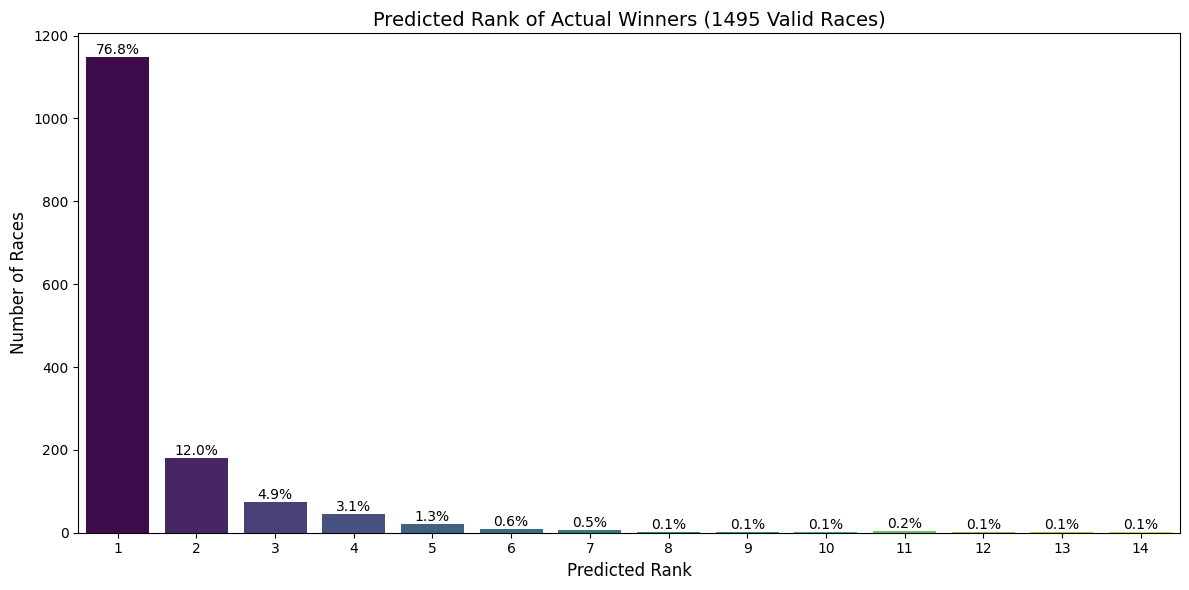

Summary of Winner's Predicted Rank:
count    1495.000000
mean        1.493645
std         1.257824
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        14.000000
Name: actual_winner_predicted_rank, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=xgb_engine_full_check,
    x='actual_winner_predicted_rank',
    hue='actual_winner_predicted_rank',
    palette='viridis',
    legend=False,
    order=sorted(xgb_engine_full_check['actual_winner_predicted_rank'].unique())
)

plt.title('Predicted Rank of Actual Winners (1495 Valid Races)', fontsize=14)
plt.xlabel('Predicted Rank', fontsize=12)
plt.ylabel('Number of Races', fontsize=12)

# Add percentage labels on top of bars
total_races = len(xgb_engine_full_check)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height/total_races:.1%}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Quick statistical summary
print("Summary of Winner's Predicted Rank:")
print(xgb_engine_full_check['actual_winner_predicted_rank'].describe())


In [ ]:
print("Total test rows:", len(nn_test_df))
print("Total test races:", nn_test_df["race_key"].nunique())

winner_counts = (
    nn_test_df.groupby("race_key")["winner"]
    .sum()
    .value_counts()
    .sort_index()
)

print("\nWinner counts per race:")
print(winner_counts)

valid_single_winner_races = (
    nn_test_df.groupby("race_key")["winner"]
    .sum()
    .eq(1)
    .sum()
)

print("\nValid single-winner races:", valid_single_winner_races)

Total test rows: 22926
Total test races: 3070

Winner counts per race:
winner
0    1222
1    1495
2     304
3      44
4       5
Name: count, dtype: int64

Valid single-winner races: 1495


In [ ]:
no_winner_race_keys = (
    nn_test_df.groupby("race_key")["winner"]
    .sum()
    .reset_index()
)

no_winner_race_keys = no_winner_race_keys[
    no_winner_race_keys["winner"] == 0
]["race_key"]

example_no_winner = no_winner_race_keys.iloc[0]

nn_test_df[
    nn_test_df["race_key"] == example_no_winner
][[
    "race_key",
    "runner_horse",
    "runner_position",
    "winner"
]].sort_values("runner_position")

,race_key,runner_horse,runner_position,winner
117266,rac_11761334_2026-05-23,Go Just Do It (GB),2,0
117267,rac_11761334_2026-05-23,Thesecretadversary (IRE),5,0
117269,rac_11761334_2026-05-23,Gstaad (GB),5,0
117270,rac_11761334_2026-05-23,Distant Storm (GB),6,0
117268,rac_11761334_2026-05-23,Power Blue (IRE),7,0
117272,rac_11761334_2026-05-23,Pacific Avenue (IRE),8,0
117265,rac_11761334_2026-05-23,Take Charge Star (IRE),10,0


In [ ]:
multi_winner_race_keys = (
    nn_test_df.groupby("race_key")["winner"]
    .sum()
    .reset_index()
)

multi_winner_race_keys = multi_winner_race_keys[
    multi_winner_race_keys["winner"] > 1
]["race_key"]

example_multi_winner = multi_winner_race_keys.iloc[0]

nn_test_df[
    nn_test_df["race_key"] == example_multi_winner
][[
    "race_key",
    "runner_horse",
    "runner_position",
    "winner"
]].sort_values("runner_position")

,race_key,runner_horse,runner_position,winner
101756,rac_11851320_2026-04-11,Favori De Champdou (FR),1,1
101777,rac_11851320_2026-04-11,Perceval Legallois (FR),1,1
101766,rac_11851320_2026-04-11,The Real Whacker (IRE),2,0
101755,rac_11851320_2026-04-11,Final Orders (GB),2,0
101765,rac_11851320_2026-04-11,Champ Kiely (IRE),3,0
101764,rac_11851320_2026-04-11,Captain Cody (IRE),3,0
101775,rac_11851320_2026-04-11,I Am Maximus (FR),4,0
101763,rac_11851320_2026-04-11,Oscars Brother (IRE),4,0
101778,rac_11851320_2026-04-11,Three Card Brag (IRE),4,0
101774,rac_11851320_2026-04-11,Iroko (FR),5,0


The prediction engine was evaluated on the 1,495 valid test races where exactly one horse was marked as the winner. The remaining races had either no recorded winner or multiple recorded winners, so they were excluded from this prediction-engine sanity check.